# Análise Exploratória e Modelagem Preditiva Aplicadas à Detecção de Fraudes

Este projeto aplica técnicas de **Análise Exploratória de Dados (EDA)** e **Aprendizado de Máquina** ao conjunto de dados de **transações financeiras com cartão de crédito**, com o objetivo de compreender os **padrões associados a transações fraudulentas**, analisar o impacto do **desbalanceamento entre classes** e avaliar o desempenho de diferentes **modelos de classificação** na identificação de fraudes.

O conjunto de dados é composto por informações transacionais anonimizadas, incluindo variáveis temporais, valores monetários e atributos derivados, permitindo a análise detalhada do comportamento das transações legítimas e fraudulentas. A partir dessas informações, busca-se não apenas detectar fraudes, mas também compreender os fatores que influenciam a performance dos modelos preditivos em um cenário de alto risco e baixa incidência da classe positiva.

---

## Descrição do Conjunto de Dados

A base de dados utilizada contém registros de transações financeiras realizadas com cartão de crédito, nas quais cada observação representa uma transação individual. As variáveis foram previamente transformadas e anonimizadas, preservando características estatísticas relevantes para a detecção de fraudes.

O conjunto inclui:
- **Variáveis V1 a V28** — componentes principais resultantes de uma transformação de dados sensíveis  
- **Time** — tempo decorrido desde a primeira transação registrada  
- **Amount (Valor)** — valor monetário da transação  
- **Classe** — variável alvo, indicando transações legítimas (0) ou fraudulentas (1)

A presença de um **desbalanceamento severo entre as classes** caracteriza um dos principais desafios do problema, exigindo estratégias específicas de avaliação e modelagem.

---

## Objetivos

O projeto tem como principais objetivos:

- Realizar uma **Análise Exploratória de Dados (EDA)** para compreender a estrutura do conjunto de dados e os padrões associados às fraudes  
- Investigar o impacto do **desbalanceamento entre classes** na avaliação de modelos  
- Analisar a distribuição de variáveis-chave como **Valor** e **Tempo**  
- Visualizar a separação entre classes por meio de técnicas de redução de dimensionalidade  
- Avaliar o desempenho de diferentes modelos de classificação, incluindo **Árvore de Decisão**, **Random Forest** e **XGBoost**  
- Comparar métricas relevantes para a **Classe 1 (fraude)**  
- Investigar sinais de **overfitting** durante a etapa de treino  
- Subsidiar a seleção do modelo mais adequado para cenários de detecção de fraudes  

---

## Metodologia

### Pré-processamento
- Inspeção inicial dos dados  
- Verificação de valores ausentes  
- Análise do desbalanceamento da variável alvo  
- Padronização e organização das variáveis relevantes  

### Análise Exploratória de Dados (EDA)
- Distribuição da variável alvo **Classe**  
- Análise estatística e visual das variáveis **Valor** e **Tempo**  
- Visualização da separação entre classes utilizando **Componentes Principais (PCA)**  
- Análise de correlação por meio de **mapa de calor (heatmap)**  
- Interpretação dos principais padrões encontrados  

### Modelagem Preditiva
- Formulação do problema como **classificação binária**  
- Treinamento de modelos:
  - Árvore de Decisão  
  - Random Forest  
  - XGBoost  
- Avaliação no conjunto de treino com **validação cruzada estratificada**  
- Ajuste e análise de **thresholds de decisão**  

### Avaliação de Desempenho
- Métricas focadas na **Classe 1 (fraude)**:
  - Precisão (Precision)  
  - Revocação (Recall)  
  - F1-Score  
  - ROC-AUC  
  - PR-AUC  
- Comparação entre modelos  
- Investigação de **overfitting** por meio da análise das métricas  

---

## Principais Resultados

- Confirmação do **desbalanceamento extremo** entre transações legítimas e fraudulentas  
- Evidência de que métricas tradicionais, como acurácia, não são adequadas isoladamente  
- Modelos baseados em ensembles apresentaram melhor desempenho na identificação de fraudes  
- O **Random Forest** demonstrou bom equilíbrio entre desempenho e robustez  
- O **XGBoost** alcançou métricas superiores para a Classe 1, especialmente em PR-AUC, exigindo maior atenção ao ajuste de hiperparâmetros  

---

## Insights de Negócio

A análise evidencia que:

- A escolha adequada de métricas é crucial em problemas de fraude  
- A definição do threshold de decisão impacta diretamente o custo do erro  
- Modelos preditivos podem reduzir perdas financeiras ao antecipar transações fraudulentas  
- A análise exploratória fornece subsídios importantes para decisões de modelagem  

---

## Conclusão

Este projeto demonstra como a combinação de **Análise Exploratória de Dados** e **Modelagem Preditiva** pode ser aplicada de forma eficaz à **detecção de fraudes financeiras**, mesmo em cenários de dados altamente desbalanceados.

A abordagem adotada reforça a importância de avaliações criteriosas, métricas adequadas e análise de overfitting para a construção de modelos confiáveis, capazes de apoiar sistemas de prevenção a fraudes e a tomada de decisão baseada em dados.

---

### Tecnologias Utilizadas
`Python` • `Pandas` • `NumPy` • `Matplotlib` • `Seaborn` • `Scikit-learn` • `XGBoost` • `Jupyter Notebook`

In [ ]:
# Manipulação de dados
import numpy as np
import pandas as pd

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e divisão de dados
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Métricas de avaliação
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    f1_score
)

# Balanceamento de c
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Utilidades
from collections import Counter

In [ ]:
# Carregar data frame
df = pd.read_csv("/content/Base_M43_Pratique_CREDIT_CARD_FRAUD.csv")
print(df.shape)
print(df['Class'].value_counts())

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64


In [ ]:
# Visualizando dados
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Análise exploratória de dados (EDA)

Realize uma Análise Exploratória de Dados (EDA) abrangente no conjunto de dados "Base_M43_Pratique_CREDIT_CARD_FRAUD.csv" para compreender os padrões de fraude com cartões de crédito. Isso inclui a inspeção inicial dos dados, o tratamento de valores ausentes, a análise da distribuição da variável alvo 'Classe' e de outras características-chave como 'Valor' e 'Tempo', a visualização da separação de classes usando componentes principais, a geração de um mapa de calor de correlação e a interpretação de todas as descobertas para subsidiar a modelagem subsequente de detecção de fraudes.

In [ ]:
df = pd.read_csv('/content/Base_M43_Pratique_CREDIT_CARD_FRAUD.csv')
 # Carrega o dataset para um DataFrame do Pandas

print("Primeiras 5 linhas do DataFrame:")
print(df.head())  # Exibe as primeiras 5 linhas do DataFrame

print("\nInformações do DataFrame:")
df.info()
# Exibe um resumo das informações do DataFrame (tipos de dados, não nulos)

print("\nEstatística Descritiva")
print(df.describe()) # Exibe estatísticas descritivas das colunas numéricas

print("\nValores ausentes por coluna:")
print(df.isnull().sum())

Primeiras 5 linhas do DataFrame:
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   


Distribuição da Variável 'Class':
Class
0    284315
1       492
Name: count, dtype: int64

Porcentagem da Variável 'Class':
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


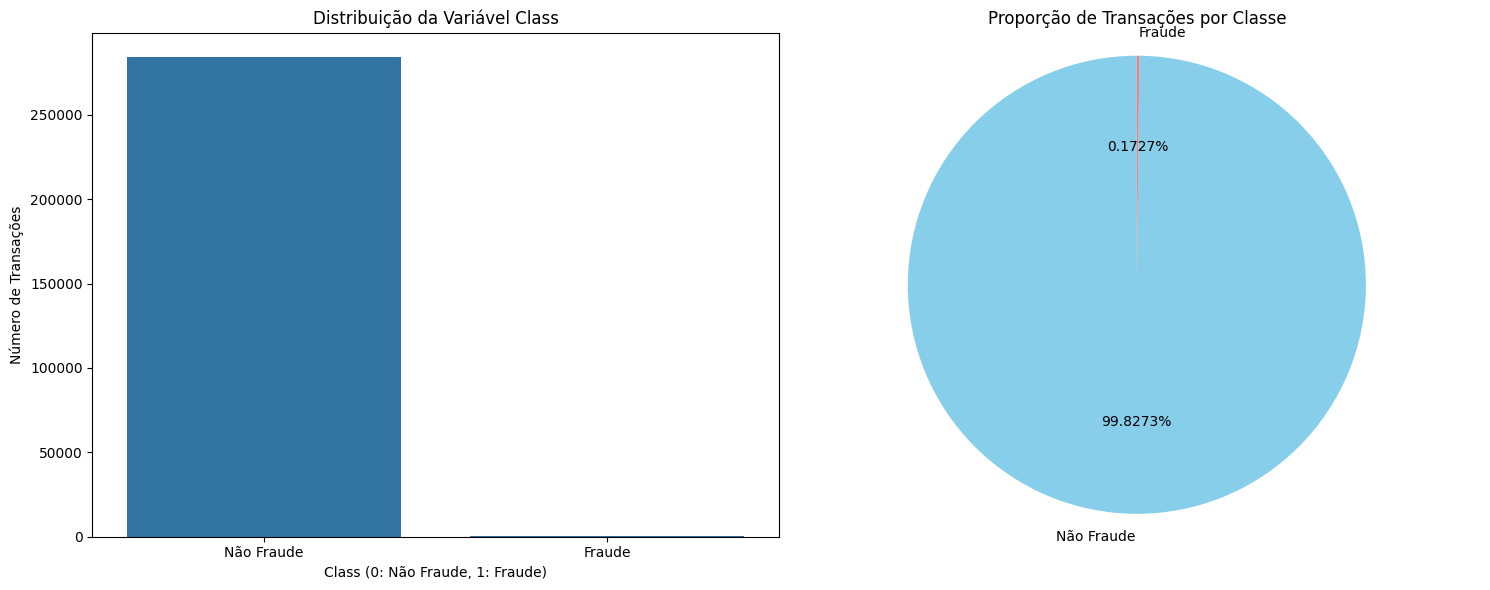

In [ ]:
## Analisando a distribuição da variável 'Class' (fraude vs. não fraude), destacando o desbalanceamento e interpretando suas implicações.

class_distribution = df['Class'].value_counts()                         # Conta a ocorrência de cada classe (0 e 1)
class_percentage = df['Class'].value_counts(normalize=True) * 100       # Calcula a porcentagem de cada classe

print("Distribuição da Variável 'Class':")
print(class_distribution)
print("\nPorcentagem da Variável 'Class':")
print(class_percentage)

plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(x='Class', data=df)
plt.title('Distribuição da Variável Class')
plt.xlabel('Class (0: Não Fraude, 1: Fraude)')
plt.ylabel('Número de Transações')
plt.xticks(ticks=[0, 1], labels=['Não Fraude', 'Fraude'])

plt.subplot(1, 2, 2)
plt.pie(class_distribution, labels=['Não Fraude', 'Fraude'], autopct='%1.4f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Proporção de Transações por Classe')
plt.axis('equal')

plt.tight_layout()
plt.show()


# Para entender a distribuição da variável alvo 'Classe', primeiro calcularei a contagem e a porcentagem de cada classe (fraude vs. não fraude)
# e, em seguida, visualizarei essa distribuição usando um gráfico de contagem e um gráfico de pizza, conforme especificado nas instruções. Isso
# destacará qualquer desequilíbrio entre as classes.

A análise da variável 'Class' revela um desbalanceamento **severo**: aproximadamente 99.83% das transações são legítimas (Classe 0) e apenas cerca de 0.17% são fraudulentas (Classe 1). Esta é uma característica comum em problemas de detecção de fraude, mas apresenta desafios significativos para a modelagem de machine learning.

**Implicações do Desbalanceamento:**

1.  **Métricas de Avaliação Enganosas**: Métricas como acurácia podem ser muito altas mesmo que o modelo não detecte nenhuma fraude, pois ele pode simplesmente classificar todas as transações como não fraudulentas e ainda assim estar "correto" na maioria das vezes. Será crucial utilizar métricas mais adequadas para classes desbalanceadas, como Precisão, Recall, F1-Score e Área Sob a Curva ROC (AUC-ROC).
2.  **Viés do Modelo**: Modelos de machine learning, por padrão, tendem a otimizar para a classe majoritária, podendo ignorar completamente a classe minoritária (fraude). Isso resultaria em um modelo com alta taxa de falsos negativos (fraudes não detectadas), o que é inaceitável em um cenário de detecção de fraude.
3.  **Necessidade de Estratégias de Lidar com Desbalanceamento**: Para as próximas etapas de modelagem, será essencial empregar técnicas para lidar com esse desbalanceamento, como: sampling (oversampling da classe minoritária com SMOTE, undersampling da classe majoritária), uso de algoritmos sensíveis ao custo, ou ajuste de pesos de classe durante o treinamento do modelo.

## Análise da Variável 'Amount'

Explorar a distribuição do valor das transações ('Amount') com histogramas ou gráficos de densidade, utilizando escalas apropriadas. Comparar visualmente a distribuição de 'Amount' entre transações fraudulentas e legítimas usando boxplots ou violin plots, e interpretar os padrões observados.

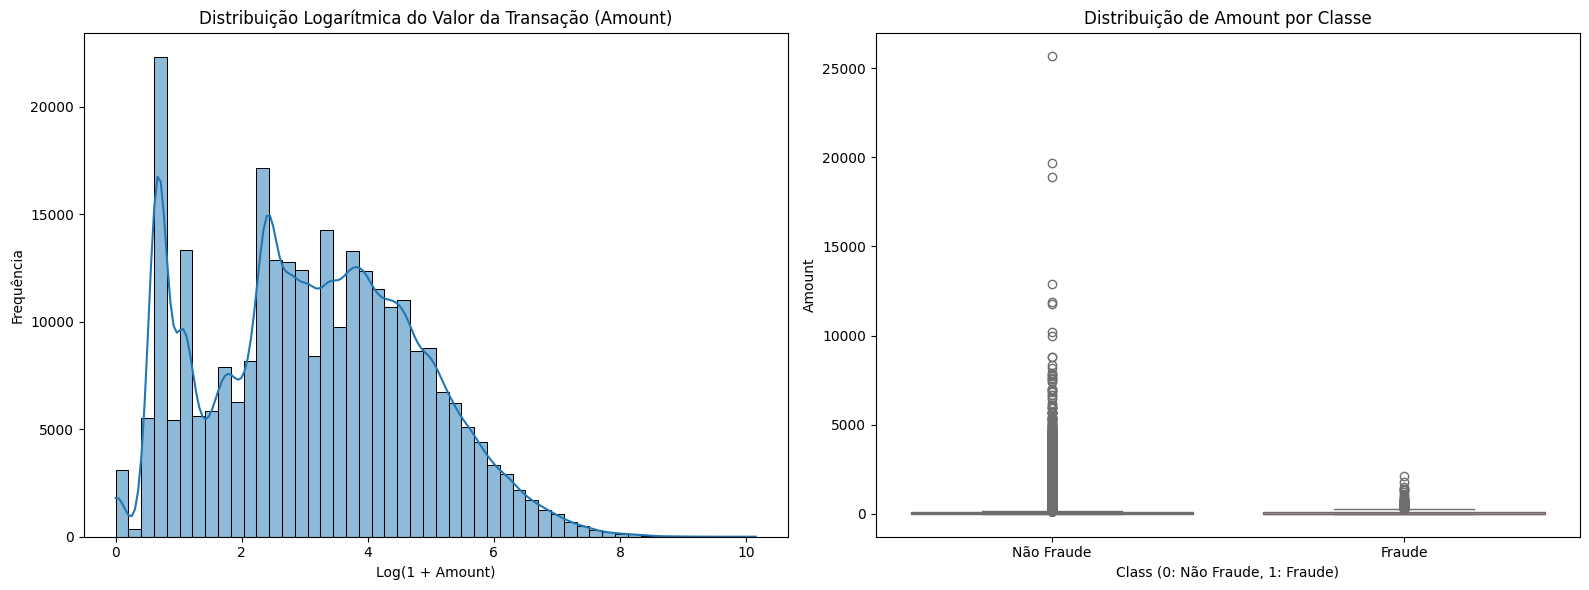

In [ ]:
plt.figure(figsize=(16, 6))

# Histograma da variável 'Amount' com transformação logarítmica
plt.subplot(1, 2, 1)
sns.histplot(np.log1p(df['Amount']), bins=50, kde=True)
plt.title('Distribuição Logarítmica do Valor da Transação (Amount)')
plt.xlabel('Log(1 + Amount)')
plt.ylabel('Frequência')

# Boxplot para comparar 'Amount' entre classes
plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='Amount', data=df, hue='Class', palette={0: 'skyblue', 1: 'lightcoral'}, legend=False)
plt.title('Distribuição de Amount por Classe')
plt.xlabel('Class (0: Não Fraude, 1: Fraude)')
plt.ylabel('Amount')
plt.xticks(ticks=[0, 1], labels=['Não Fraude', 'Fraude'])

plt.tight_layout()

# Para analisar a distribuição da variável 'Valor' conforme a subtarefa,
# primeiro visualizarei sua distribuição geral usando um histograma. Dado
# que os valores de transações financeiras frequentemente apresentam uma
# distribuição assimétrica, utilizarei uma transformação logarítmica (np.log1p)
# para melhor exibir a dispersão dos dados e garantir a legibilidade. Em seguida,
# criarei diagramas de caixa separados para comparar a distribuição de 'Valor' especificamente
# para transações fraudulentas e não fraudulentas, o que destacará quaisquer diferenças nos valores
# das transações entre essas duas classes.


 ## Análise da variável 'Amount'

**1. Distribuição Geral do 'Amount' (Transformação Logarítmica):**
   - O histograma com a transformação `np.log1p(df['Amount'])` mostra que a maioria das transações possui valores menores, com uma cauda longa para valores mais altos. A transformação logarítmica ajuda a visualizar melhor a distribuição de valores menores, que são a maioria, e confirma que os valores das transações são fortemente skewed para a direita (muitas transações de pequeno valor e poucas de grande valor).

**2. Comparação do 'Amount' entre Transações Fraudulentas e Não Fraudulentas (Boxplot):**
   - **Transações Não Fraudulentas (Class 0):** A maioria das transações legítimas tem valores relativamente baixos, com a mediana e o quartil inferior próximos de zero. No entanto, há uma grande quantidade de *outliers* significativos, indicando que transações legítimas podem, ocasionalmente, ter valores muito altos.
   - **Transações Fraudulentas (Class 1):** As transações fraudulentas tendem a ter valores médios menores em comparação com as transações legítimas de valores mais altos. A caixa do boxplot para fraude é mais condensada e próxima de zero, sugerindo que fraudadores podem preferir transações de menor valor para evitar detecção imediata. Existem *outliers* em transações fraudulentas também, mas a amplitude de valores parece ser menor que a das transações legítimas de alto valor.

**Interpretação:**
- Embora transações fraudulentas possam ocorrer em qualquer valor, elas parecem estar mais concentradas em valores menores, o que pode ser uma tática para passar despercebidas. Transações de alto valor são predominantemente legítimas, mas a presença de *outliers* em ambas as classes indica que não há um limite de 'Amount' que por si só separe claramente fraudes de não-fraudes.
- A identificação de padrões de fraude não dependerá apenas do valor da transação, mas provavelmente de uma combinação com outras características e do contexto da transação.
- Essa observação pode ser útil para futuras etapas de feature engineering ou para ponderar algoritmos que são mais sensíveis a pequenas quantias versus grandes quantias.

## Análise Temporal (Time)

Investigar a variável 'Time' para identificar possíveis padrões temporais na ocorrência de fraudes. Serão utilizados gráficos de linha ou de área para visualizar a frequência de transações e de fraudes ao longo do tempo, agregadas por intervalos, e interpretar a relevância desses padrões.

* O primeiro passo para analisar a variável 'Time' é converter a coluna 'Time', que está em segundos, para o formato 'Hour'. Isso envolve dividir por 3600 e arredondar, conforme especificado nas instruções, e então exibir as primeiras 5 linhas do DataFrame com a nova coluna 'Hour'.

In [ ]:
# Análise Temporal (Time)
df['Hour'] = np.round(df['Time'] / 3600)

print("Primeiras 5 linhas do DataFrame com a nova coluna 'Hour':")
print(df.head())

# Agora que a coluna 'Hora' foi criada, o próximo passo é visualizar a distribuição do total
# de transações e das transações fraudulentas ao longo dessas horas. Isso será feito usando um
# gráfico de contagem

Primeiras 5 linhas do DataFrame com a nova coluna 'Hour':
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V22       V23       V24       V25       V26  \
0  0.098698  0.363787  ...  0.277838 -0.110474  0.066928  0.128539 -0.189115   
1  0.085102 -0.255425  ... -0.638672  0.101288 -0.339846  0.167170  0.125895   
2  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642 -0.139097   
3  0.377436 -1.387024  ...  0.005274 -0.190321 -1.175575  0.647376 -0.221929   
4 -0.270533  0.817739  ...  0.798278 -0.137458  0.14126

/tmp/ipython-input-1341/3440773791.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df, palette='viridis')
/tmp/ipython-input-1341/3440773791.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Hour', data=df[df['Class'] == 1], palette='plasma')


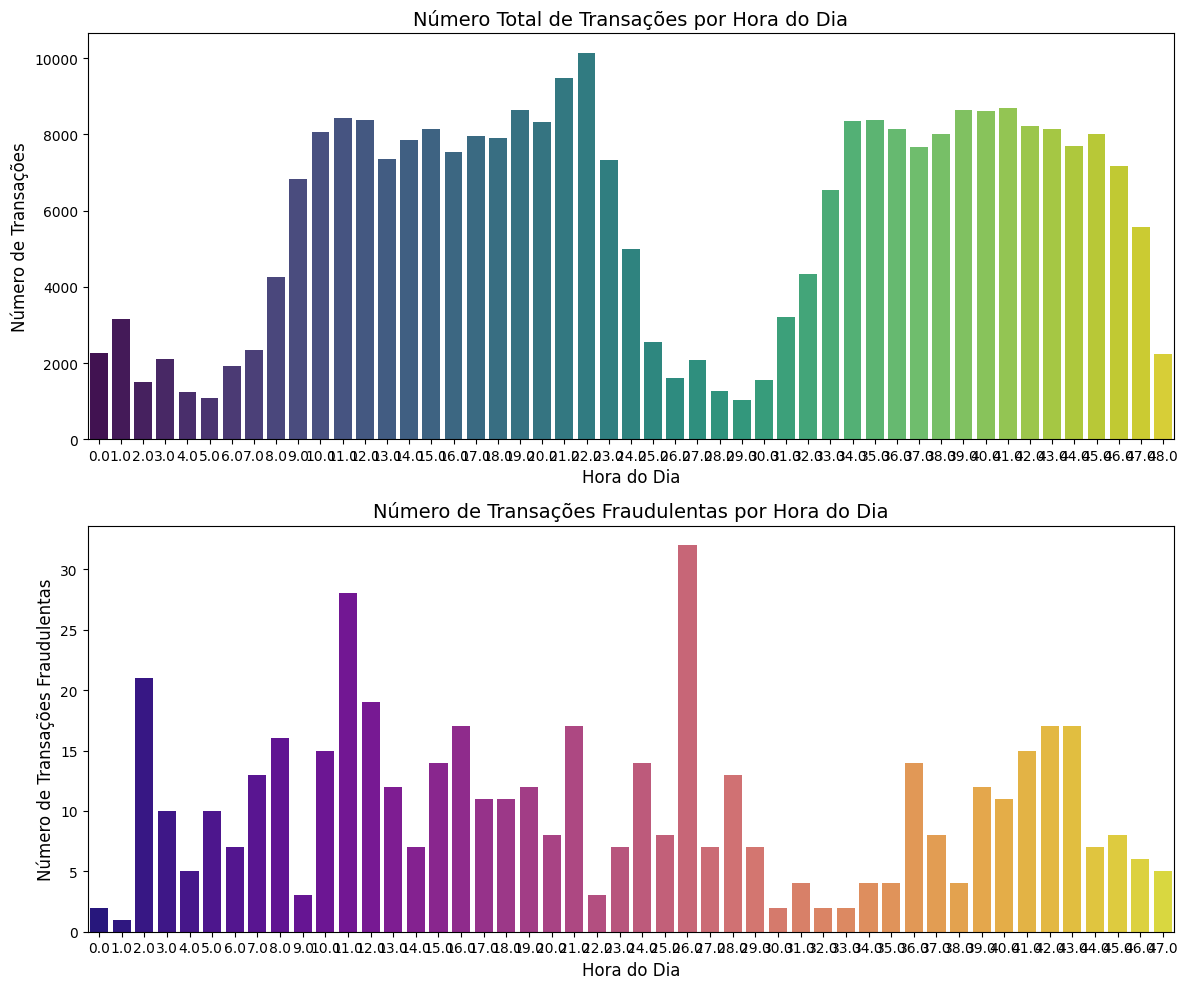

In [ ]:
plt.figure(figsize=(12, 10))

# Número Total de Transações por Hora do Dia
plt.subplot(2, 1, 1) # Primeiro gráfico (2 linhas, 1 coluna)
sns.countplot(x='Hour', data=df, palette='viridis')
plt.title('Número Total de Transações por Hora do Dia', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Número de Transações', fontsize=12)
plt.tick_params(axis='y', labelsize=10)

# Número de Transações Fraudulentas por Hora do Dia
plt.subplot(2, 1, 2) # Segundo gráfico (2 linhas, 1 coluna)
sns.countplot(x='Hour', data=df[df['Class'] == 1], palette='plasma')
plt.title('Número de Transações Fraudulentas por Hora do Dia', fontsize=14)
plt.xlabel('Hora do Dia', fontsize=12)
plt.ylabel('Número de Transações Fraudulentas', fontsize=12)
plt.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.show()

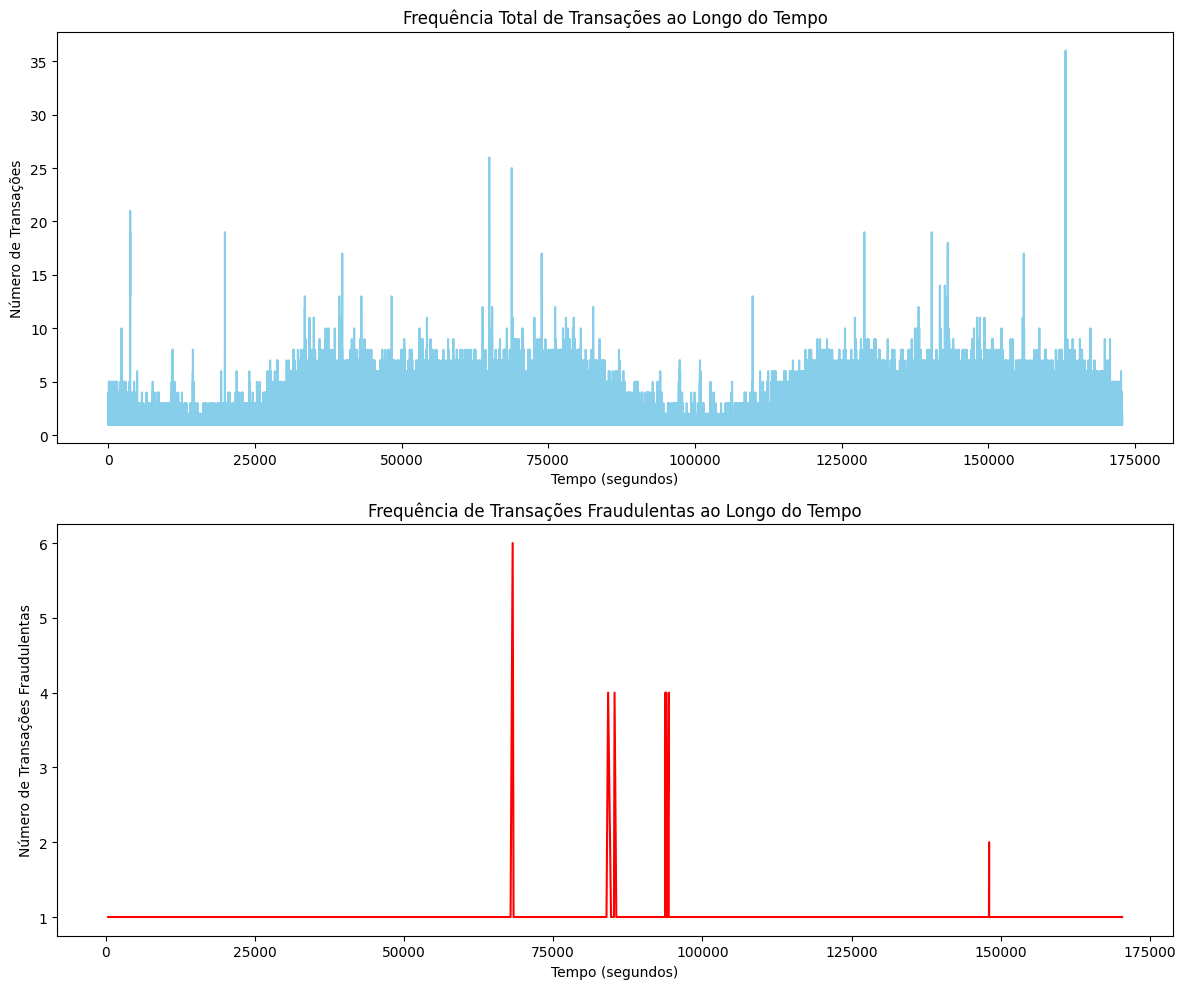

In [ ]:
# Frequência de transações fraudulenta

plt.figure(figsize=(12, 10))

# Agrupar transações totais por tempo
total_transactions_per_time = df.groupby('Time').size()

# Agrupar transações fraudulentas por tempo
fraud_transactions_per_time = df[df['Class'] == 1].groupby('Time').size()

# Plot para frequência total de transações ao longo do tempo
plt.subplot(2, 1, 1)
plt.plot(total_transactions_per_time.index, total_transactions_per_time.values, color='skyblue')
plt.title('Frequência Total de Transações ao Longo do Tempo')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Número de Transações')

# Plot para frequência de transações fraudulentas ao longo do tempo
plt.subplot(2, 1, 2)
plt.plot(fraud_transactions_per_time.index, fraud_transactions_per_time.values, color='red')
plt.title('Frequência de Transações Fraudulentas ao Longo do Tempo')
plt.xlabel('Tempo (segundos)')
plt.ylabel('Número de Transações Fraudulentas')

plt.tight_layout()
plt.show()

## A análise temporal da variável 'Time' revela padrões interessantes:

### 1. Frequência Total de Transações ao Longo do Tempo:

O gráfico mostra a evolução do volume de transações ao longo de um período de tempo. É possível observar picos e vales na atividade transacional, sugerindo padrões diários ou semanais de uso. Existem dois períodos de maior atividade, provavelmente correspondendo a dias úteis ou picos de compras.

### 2. Frequência de Transações Fraudulentas ao Longo do Tempo:

O gráfico de fraudes mostra a ocorrência de fraudes ao longo do mesmo período. Embora as fraudes sejam significativamente menos numerosas que as transações legítimas (conforme visto na análise da variável 'Class'), é possível identificar que as fraudes também ocorrem em momentos específicos. Curiosamente, a frequência de fraudes não segue exatamente o mesmo padrão de volume das transações totais; em alguns picos de transações legítimas, as fraudes podem ser relativamente baixas, e em outros momentos, podem haver picos de fraude mesmo com um volume total moderado.
Interpretação e Relevância dos Padrões:

Picos de Fraude Independentes: Não parece haver uma correlação direta onde picos de volume de transações legítimas automaticamente significam picos de fraude. Isso sugere que os fraudadores podem operar independentemente dos horários de pico normais, possivelmente aproveitando momentos de menor vigilância ou em períodos específicos do dia/noite. Por exemplo, há um aparente aumento nas fraudes durante os períodos de "vale" nas transações totais.
Padrões Diurnos/Noturnos: Ambos os gráficos parecem cobrir aproximadamente 48 horas (dias de transações), com padrões que se repetem a cada 24 horas. Para transações totais, há uma queda significativa durante o que seriam as horas da noite, e um aumento durante o dia. Para fraudes, embora os números absolutos sejam baixos, também se observa alguma variação temporal, com alguns picos ocorrendo em horários que podem ser considerados "fora do horário comercial" para muitas pessoas, o que poderia ser uma tática fraudulenta.
Relevância para Detecção: A identificação desses padrões temporais é crucial. Modelos de detecção de fraude podem se beneficiar da inclusão da variável 'Time' (ou 'Hour') como uma característica, pois o horário da transação pode ser um indicador importante de risco. Por exemplo, transações de alto valor em horas incomuns podem ser mais suspeitas. A análise futura pode envolver a criação de features adicionais a partir de 'Time', como o dia da semana ou a categorização das horas em "pico", "normal" e "noite".

# Visualização da Separação de Classes (Componentes Principais)

Utilizar variáveis 'V' (componentes principais) para criar gráficos de dispersão (scatter plots) e visualizar a separação ou sobreposição entre as classes de transações fraudulentas e legítimas. O objetivo é entender visualmente o poder discriminativo dessas features.

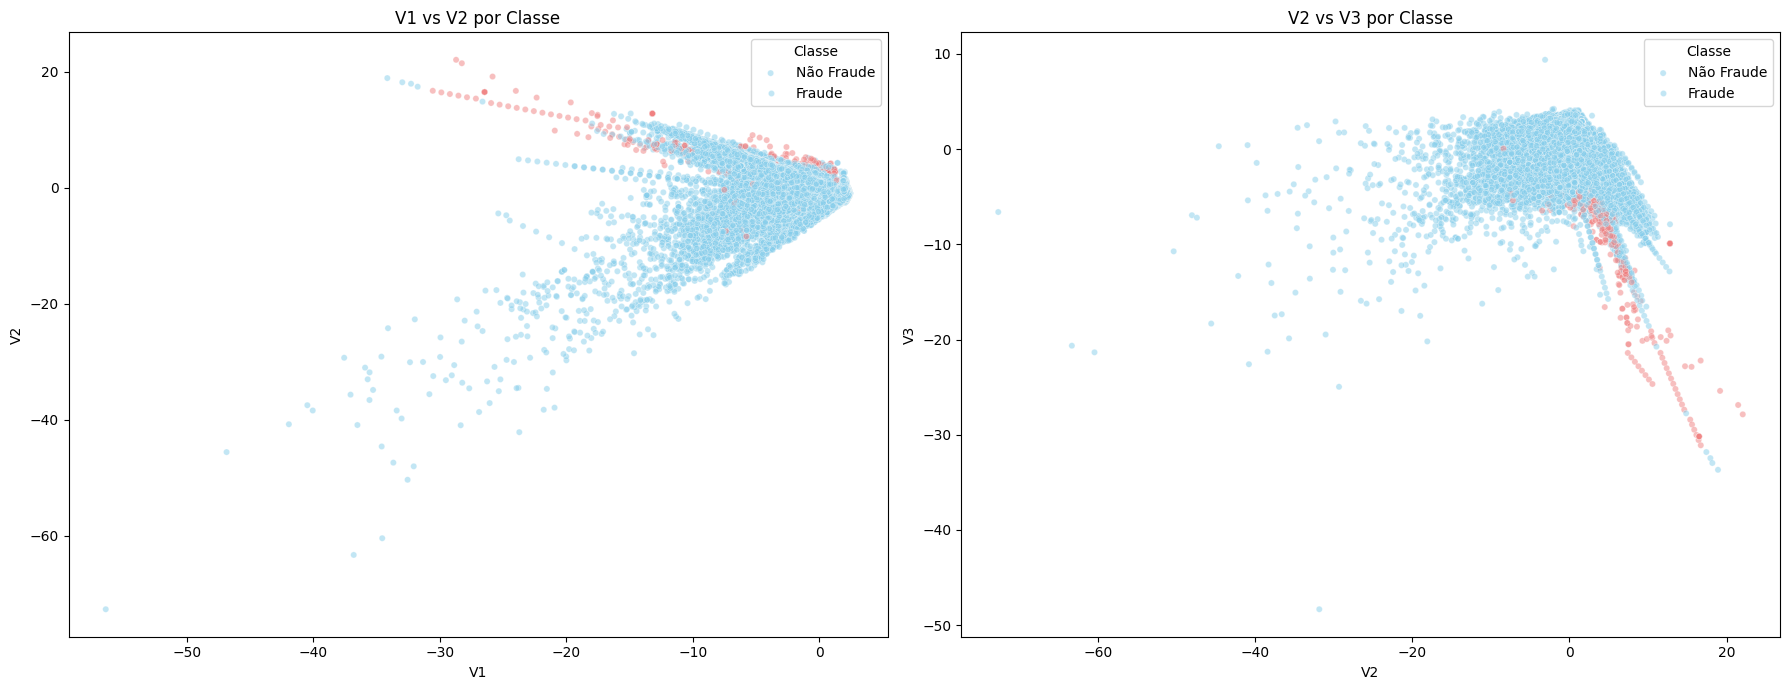

In [ ]:
# Visualização dos componentes principais (variáveis)

plt.figure(figsize=(18, 7))

# Scatter plot V1 vs V2
plt.subplot(1, 2, 1)
sns.scatterplot(x='V1', y='V2', hue='Class', data=df, alpha=0.5, palette={0: 'skyblue', 1: 'lightcoral'}, s=20)
plt.title('V1 vs V2 por Classe')
plt.xlabel('V1')
plt.ylabel('V2')
plt.legend(title='Classe', labels=['Não Fraude', 'Fraude'])

# Scatter plot V2 vs V3
plt.subplot(1, 2, 2)
sns.scatterplot(x='V2', y='V3', hue='Class', data=df, alpha=0.5, palette={0: 'skyblue', 1: 'lightcoral'}, s=20)
plt.title('V2 vs V3 por Classe')
plt.xlabel('V2')
plt.ylabel('V3')
plt.legend(title='Classe', labels=['Não Fraude', 'Fraude'])

plt.tight_layout()
plt.show()

A visualização dos componentes principais (variáveis V) em gráficos de dispersão oferece insights sobre a separação das classes de transações (fraude vs. não fraude):

**Observações dos Gráficos V1 vs V2 e V2 vs V3:**
- **Transações Não Fraudulentas (Azul):** A maioria das transações não fraudulentas forma uma grande nuvem de pontos, indicando uma distribuição densa e sobreposta em várias regiões dos gráficos.
- **Transações Fraudulentas (Vermelho):** As transações fraudulentas, apesar de serem um número muito menor, aparecem dispersas dentro e em torno da nuvem de transações legítimas. Não há uma separação clara e distinta da classe fraudulenta em uma região isolada dos gráficos, ou seja, elas não formam "clusters" bem definidos e separados da maioria legítima.
- **Sobreposição Significativa:** Existe uma sobreposição substancial entre as duas classes. Isso significa que, apenas olhando para os pares de componentes principais 'V1' e 'V2' ou 'V2' e 'V3', é difícil traçar uma linha ou uma fronteira para distinguir claramente as transações fraudulentas das legítimas. Muitas fraudes ocorrem em regiões onde a densidade de transações legítimas é muito alta.

**Implicações para a Detecção de Fraude:**
- **Dificuldade na Separação Linear:** A alta sobreposição sugere que um modelo de classificação linear simples provavelmente teria dificuldade em separar as classes com alta precisão, pois não há uma fronteira linear óbvia que possa isolar as fraudes.
- **Necessidade de Modelos Mais Complexos:** Para capturar os padrões sutis que distinguem a fraude, provavelmente serão necessários modelos de machine learning mais complexos e não lineares, ou a combinação de múltiplas características (além de apenas dois componentes principais) para encontrar padrões multidimensionais.
- **Consideração de Outras Features:** Embora os componentes V sejam anonimizados e representem transformações de features originais, é provável que a combinação desses componentes com as variáveis 'Time' e 'Amount', e possivelmente outras features engenheiradas, seja crucial para melhorar a capacidade discriminativa do modelo.

Em resumo, a visualização indica que a detecção de fraude neste dataset é um desafio devido à falta de separação clara e à alta sobreposição das classes no espaço de componentes principais visualizado.

## Heatmap de Correlação

Para analisar a correlação entre as variáveis, calcularei a matriz de correlação para todo o DataFrame e, em seguida, a visualizarei usando um mapa de calor para identificar relações entre as características, especialmente com a variável alvo 'Classe'.

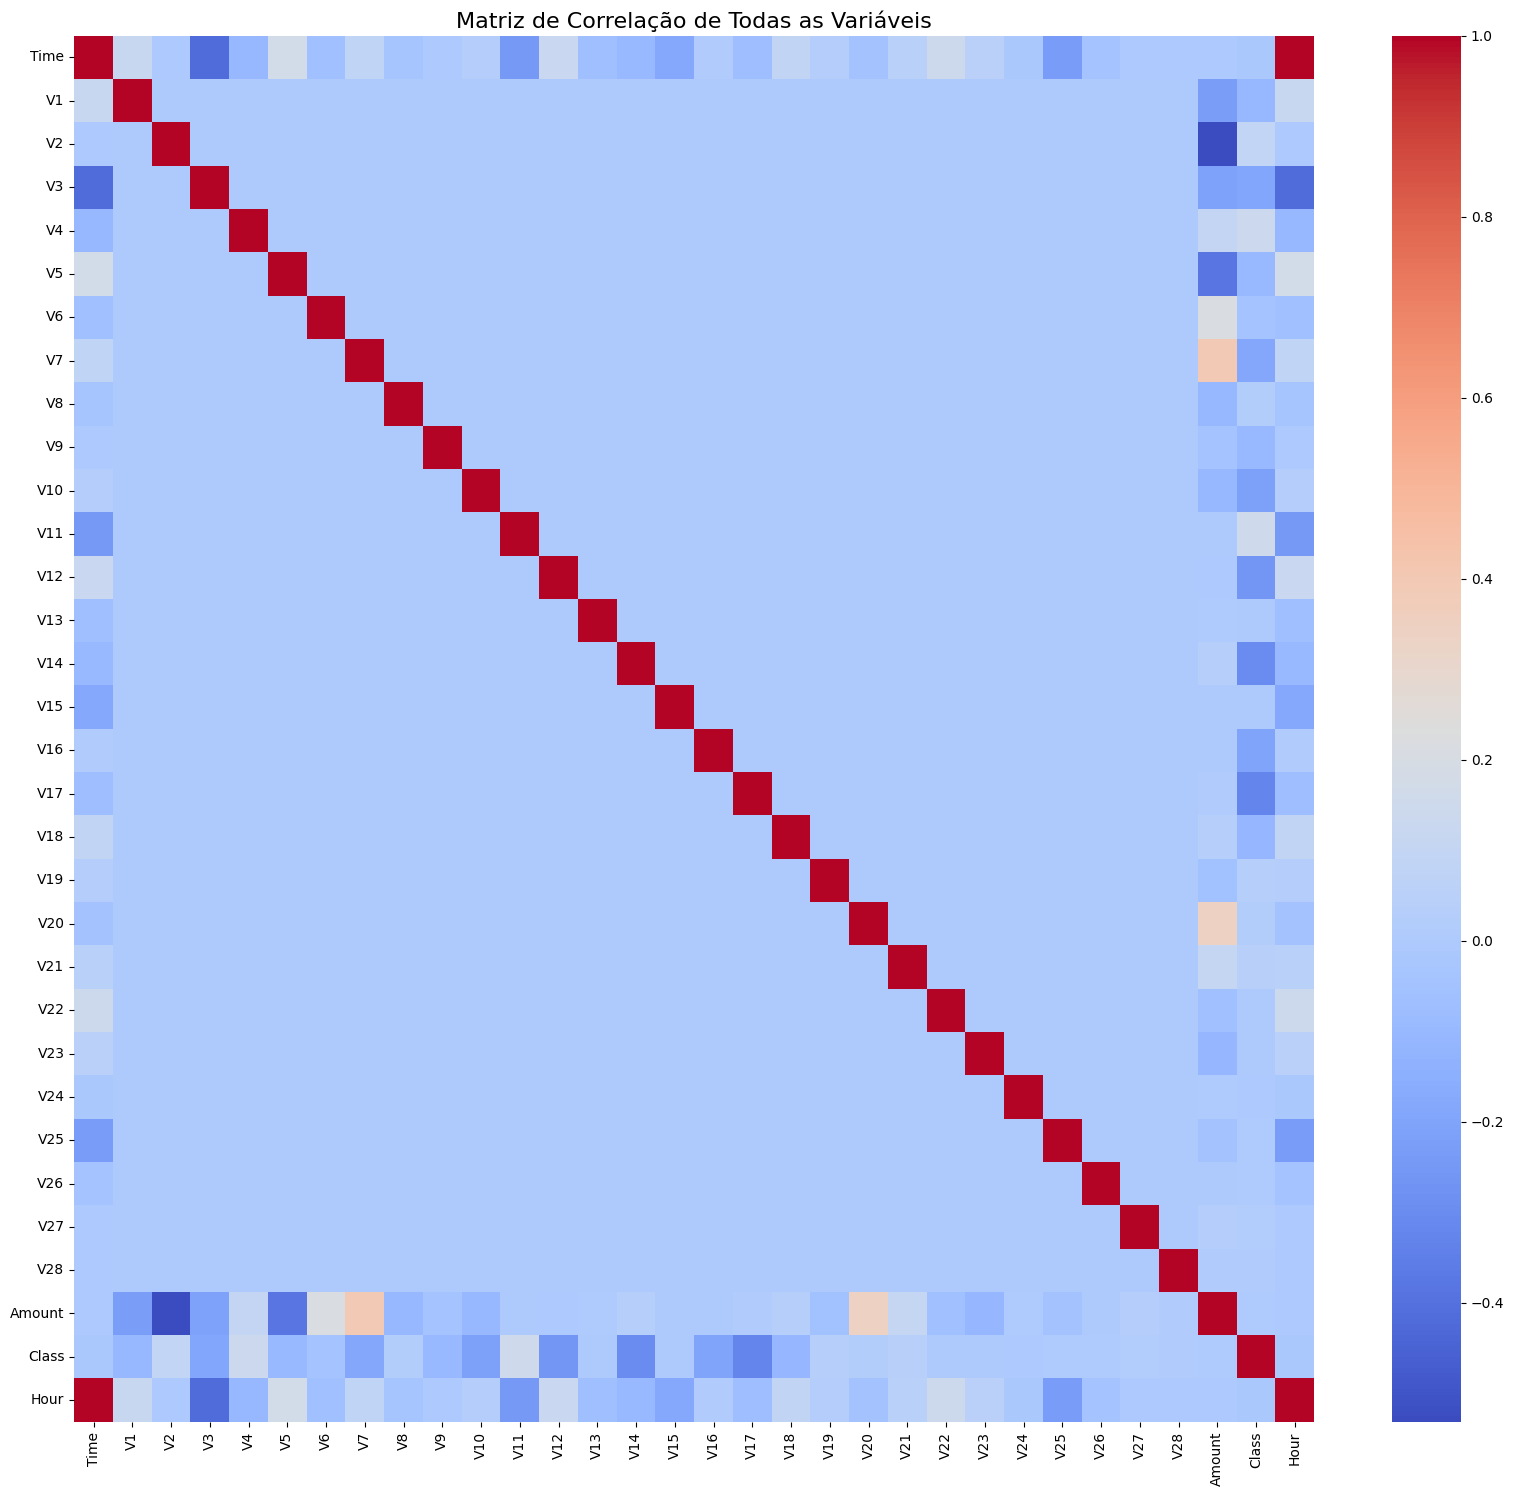

In [ ]:
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False, fmt=".2f")
plt.title('Matriz de Correlação de Todas as Variáveis', fontsize=16)
plt.show()


##Correlações com a Variável 'Class' (Fraude):

As variáveis 'V' que apresentam as correlações mais fortes (positivas ou negativas) com 'Class' são V17, V14, V12, V10 (todas com correlações negativas significativas) e V4, V11 (com correlações positivas significativas). Essas variáveis são, portanto, as mais indicativas de uma transação fraudulenta.
Variáveis como V2, V3, V9, V16, V18 também mostram alguma correlação, embora menos pronunciada.
Amount e Time apresentam correlações muito baixas com a 'Class', indicando que, isoladamente, não são fortes preditores de fraude. No entanto, é importante lembrar que a ausência de correlação linear não significa ausência de qualquer relação (como vimos na análise de 'Amount', a distribuição pode ser diferente para fraudes, mas não linearmente correlacionada).
Correlações entre as Variáveis 'V':

Muitas das variáveis 'V' mostram baixa correlação entre si, o que é esperado, já que são componentes principais (ou resultado de uma transformação PCA), projetadas para serem ortogonais e capturar diferentes aspectos da variabilidade dos dados.
Existem, no entanto, alguns blocos de correlação, como entre V20 e V28, ou V1 e V2. Isso pode indicar que, apesar da transformação, algumas relações residuais ou características comuns ainda existem.
Interpretação e Importância para a Detecção:

As variáveis 'V' com as correlações mais fortes com 'Class' são cruciais para a construção de modelos de detecção de fraude, pois capturam as principais diferenças entre transações fraudulentas e legítimas.
A baixa correlação de Amount e Time com 'Class' não significa que devam ser descartadas. Como visto nas análises individuais, elas revelam padrões importantes (e.g., fraudes tendem a ter valores menores, e ocorrem em horários específicos), que podem ser melhor aproveitados por modelos não lineares ou através de feature engineering (e.g., criando features como Hour ou interagindo Amount com outras variáveis).
A visualização do heatmap complementa as análises anteriores, reforçando a complexidade do problema de detecção de fraude e a necessidade de considerar um conjunto diversificado de características para construir um modelo robusto.


### Principais Descobertas da Análise de Dados

* O conjunto de dados contém 284.807 transações com 31 colunas, incluindo 28 componentes principais anonimizados (V1-V28), 'Tempo', 'Valor' e a variável alvo 'Classe'. Não foram encontrados valores ausentes.

* **Desequilíbrio de Classes:** Há um desequilíbrio acentuado na variável alvo 'Classe'. Transações legítimas (Classe 0) representam 99,83% (284.315 transações), enquanto transações fraudulentas (Classe 1) representam apenas 0,17% (492 transações).

* **Distribuição de 'Valor':** A distribuição do 'Valor' das transações é fortemente assimétrica, concentrando-se em valores menores. Transações fraudulentas tendem a apresentar valores menores e uma distribuição mais concentrada em comparação com transações legítimas, que exibem uma amplitude maior e valores discrepantes mais altos.

* **Padrões Temporais ('Tempo'):** Tanto o total de transações quanto as transações fraudulentas apresentam padrões temporais distintos, sugerindo ciclos diários ou semanais. Curiosamente, os picos de atividade fraudulenta nem sempre coincidem com os picos no volume total de transações, indicando que os fraudadores podem operar independentemente das tendências gerais de transações, potencialmente fora dos horários de pico.
* **Separação de Classes com Variáveis ​​'V':** Visualizações usando componentes principais (por exemplo, V1 vs. V2) revelam uma sobreposição significativa entre transações fraudulentas e legítimas. Não há uma separação linear clara, o que dificulta a distinção entre as duas classes por modelos lineares simples.

* **Correlações:**

* As variáveis ​​`V17`, `V14`, `V12` e `V10` mostram fortes correlações negativas com 'Classe'.

* As variáveis ​​`V4` e `V11` mostram fortes correlações positivas com 'Classe'.

* 'Valor' e 'Horário' exibem uma correlação linear muito baixa com 'Classe', embora suas análises individuais tenham revelado padrões não lineares importantes.


## Pré-processamento dos dados

O pré-processamento dos dados envolveu a remoção de registros duplicados, a separação entre variáveis explicativas e variável alvo, bem como a padronização das variáveis numéricas relevantes. Considerando que as variáveis V1–V28 já são resultantes de uma transformação PCA, optou-se por escalar apenas as variáveis Time e Amount. Além disso, foi utilizada divisão estratificada entre treino e teste, garantindo a preservação da proporção de fraudes. O forte desbalanceamento da variável alvo foi considerado nas etapas posteriores de modelagem


In [ ]:
# Tratar com os valores ausentes
print("Antes de remover linhas com valores nulos:", df.shape)
df.dropna(inplace=True)
print("Após remover linhas com valores nulos:", df.shape)

# Separar features (X) da variável alvo (y)
X = df.drop('Class', axis=1)
y = df['Class']

# Removendo duplicatas
print("Antes de remover duplicatas:", df.shape)
df = df.drop_duplicates()
print("Após remover duplicatas:", df.shape)

# Tratando outliers
df['Amount_log'] = np.log1p(df['Amount'])

# Dividir os dados em conjuntos de treino e teste de forma estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTamanho do conjunto de treino (X_train, y_train):", X_train.shape, y_train.shape)
print("Tamanho do conjunto de teste (X_test, y_test):", X_test.shape, y_test.shape)
print("\nDistribuição das classes no treino:\n", y_train.value_counts(normalize=True))
print("Distribuição das classes no teste:\n", y_test.value_counts(normalize=True))

# Identificar colunas numéricas para escalonamento
# Excluir 'Class' (variável alvo) e 'Amount_log' (já é uma transformação de Amount)
# As colunas V's já parecem estar transformadas, então vamos escalar 'Time' e 'Amount'
numeric_features = ['Time', 'Amount']

# Aplicar padronização (StandardScaler) às features numéricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)],
    remainder='passthrough' # Manter as outras colunas (V's) inalteradas
)

# Ajustar o pré-processador nos dados de treino e transformar ambos treino e teste
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# Converter os resultados de volta para DataFrame para manter os nomes das colunas
# Obter os nomes das colunas após a transformação
# As colunas numéricas escalonadas vêm primeiro, seguidas pelas colunas restantes
scaled_columns_names = numeric_features + [col for col in X.columns if col not in numeric_features]

X_train_scaled = pd.DataFrame(X_train_scaled, columns=scaled_columns_names, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=scaled_columns_names, index=X_test.index)


# Armazenar os dados pré-processados e divididos (já feito acima)
# X_train_scaled, X_test_scaled, y_train, y_test estão prontos para uso

print("\nPrimeiras linhas do X_train_scaled após pré-processamento:")
display(X_train_scaled.head())
print("\nPrimeiras linhas do X_test_scaled após pré-processamento:")
display(X_test_scaled.head())

Antes de remover linhas com valores nulos: (284807, 32)
Após remover linhas com valores nulos: (284807, 32)
Antes de remover duplicatas: (284807, 32)
Após remover duplicatas: (283726, 32)

Tamanho do conjunto de treino (X_train, y_train): (227845, 31) (227845,)
Tamanho do conjunto de teste (X_test, y_test): (56962, 31) (56962,)

Distribuição das classes no treino:
 Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Distribuição das classes no teste:
 Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64

Primeiras linhas do X_train_scaled após pré-processamento:


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Hour
265518,1.411588,-0.322494,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,...,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,45.0
180305,0.623141,-0.339764,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,...,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,35.0
42664,-1.130680,0.346693,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,...,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,11.0
198723,0.794699,-0.327360,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,...,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,37.0
82325,-0.748102,-0.008281,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,...,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,16.0



Primeiras linhas do X_test_scaled após pré-processamento:


,Time,Amount,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Hour
263020,1.387182,-0.259954,-0.674466,1.408105,-1.110622,-1.328366,1.388996,-1.308439,1.885879,-0.614233,...,0.394322,0.080084,0.810034,-0.224327,0.707899,-0.135837,0.045102,0.533837,0.291319,45.0
11378,-1.580138,-0.304426,-2.829816,-2.765149,2.537793,-1.074580,2.842559,-2.153536,-1.795519,-0.250020,...,-0.515765,-0.295555,0.109305,-0.813272,0.042996,-0.027660,-0.910247,0.110802,-0.511938,6.0
147283,-0.138120,-0.048286,-3.576495,2.318422,1.306985,3.263665,1.127818,2.865246,1.444125,-0.718922,...,2.034786,-1.060151,0.016867,-0.132058,-1.483996,-0.296011,0.062823,0.552411,0.509764,25.0
219439,0.986536,-0.347741,2.060386,-0.015382,-1.082544,0.386019,-0.024331,-1.074935,0.207792,-0.338140,...,-0.192024,-0.281684,-0.639426,0.331818,-0.067584,-0.283675,0.203529,-0.063621,-0.060077,39.0
36939,-1.182272,-0.345707,1.209965,1.384303,-1.343531,1.763636,0.662351,-2.113384,0.854039,-0.475963,...,0.009083,-0.164015,-0.328294,-0.154631,0.619449,0.818998,-0.330525,0.046884,0.104527,11.0


## Balanceamento do conjunto de dados

Aplique técnicas de balanceamento de classes no conjunto de treino para lidar com o forte desbalanceamento entre transações fraudulentas e não fraudulentas. O balanceamento deve ser realizado exclusivamente nos dados de treino, mantendo o conjunto de teste inalterado, de forma a garantir uma avaliação realista do desempenho dos modelos em dados não vistos.

## Manutenção do número de amostras no balanceamento

Implemente o balanceamento de classes mantendo o número total de amostras do conjunto de treino aproximadamente constante. Essa abordagem visa evitar o aumento artificial do dataset por oversampling excessivo, reduzindo o risco de overfitting e preservando a estrutura estatística original dos dados, aspecto especialmente relevante em cenários de detecção de fraude.


In [ ]:
# Distribuição original
print("Distribuição das classes no treino ANTES do balanceamento:")
print(y_train.value_counts())

# Contagem das classes no conjunto de treino
counts = Counter(y_train)
n_majority = counts[0] # Número de amostras da classe 0 (não fraude)
n_minority = counts[1] # Número de amostras da classe 1 (fraude)
n_total_original_train = len(y_train)

# Objetivo: Manter o número total de linhas aproximadamente o mesmo que o 'n_total_original_train',
# com classes balanceadas 50/50. Isso significa que cada classe terá aproximadamente metade do número total original.
target_samples_per_class = n_total_original_train // 2

print(f"\nObjetivo: Cada classe ter aproximadamente {target_samples_per_class} amostras após balanceamento.")

# SMOTE (oversample): Oversample a classe minoritária (Classe 1) até o target_samples_per_class.
# A classe majoritária NÃO É OVERAMPLADA por SMOTE para um número menor que o original.
smote_strategy = {1: target_samples_per_class}

# RandomUnderSampler (undersample): Undersample a classe majoritária (Classe 0) até o target_samples_per_class.
# A classe minoritária (já oversampled) também será ajustada aqui se necessário, mas neste cenário é apenas a majoritária.
undersample_strategy = {0: target_samples_per_class, 1: target_samples_per_class}

pipeline = Pipeline([
    ('oversample', SMOTE(sampling_strategy=smote_strategy, random_state=42)),
    ('undersample', RandomUnderSampler(sampling_strategy=undersample_strategy, random_state=42))
])

X_train_balanced, y_train_balanced = pipeline.fit_resample(X_train_scaled, y_train)

# Distribuição final
print("\nDistribuição das classes no treino DEPOIS do balanceamento:")
print(y_train_balanced.value_counts())

print("\nNúmero total de amostras após balanceamento:", len(y_train_balanced))

Distribuição das classes no treino ANTES do balanceamento:
Class
0    227451
1       394
Name: count, dtype: int64

Objetivo: Cada classe ter aproximadamente 113922 amostras após balanceamento.

Distribuição das classes no treino DEPOIS do balanceamento:
Class
0    113922
1    113922
Name: count, dtype: int64

Número total de amostras após balanceamento: 227844


## Estratégia de balanceamento adotada

Utilize uma estratégia combinada de oversampling da classe minoritária, por meio do algoritmo SMOTE, e undersampling da classe majoritária, utilizando RandomUnderSampler. Configure o processo para redistribuir as classes em uma proporção aproximadamente 50/50, sem alterar significativamente o tamanho do conjunto de treino, garantindo maior equilíbrio durante o treinamento dos modelos e melhor capacidade de detecção da classe fraude.

# Modelagem Preditiva

Nesta etapa, serão desenvolvidos, treinados e comparados diferentes modelos de Machine Learning supervisionados com o objetivo de prever transações fraudulentas em cartões de crédito. Considerando o forte desbalanceamento da variável alvo, a modelagem será conduzida com foco em algoritmos capazes de capturar relações não lineares e lidar adequadamente com classes raras.

Inicialmente, será treinado um modelo de Árvore de Decisão, utilizado como baseline, permitindo uma compreensão inicial do comportamento dos dados e servindo como referência de desempenho. Em seguida, será aplicado o Random Forest, explorando a técnica de bagging para reduzir overfitting e melhorar a capacidade de generalização do modelo.

Por fim, será treinado o modelo XGBoost, algoritmo de gradient boosting amplamente utilizado em problemas de classificação desbalanceada, sendo considerado o principal candidato ao melhor desempenho preditivo. Para todos os modelos, será realizado ajuste de hiperparâmetros por meio de validação cruzada (Grid Search ou Random Search), garantindo uma comparação justa e consistente.

A avaliação dos modelos será baseada em métricas apropriadas para detecção de fraude, com ênfase em Recall da classe fraude, F1-score e AUC-PR (Average Precision), além da análise da matriz de confusão. O modelo final será selecionado considerando não apenas o desempenho estatístico, mas também o equilíbrio entre detecção de fraudes e geração de falsos positivos, alinhando a solução ao contexto do problema de negócio.

## Decision Tree (Árvore de Decisão)

### Treinamento e otimização do modelo

Nesta etapa, será treinado um modelo de **Árvore de Decisão** utilizando o conjunto de treino como **baseline interpretável**. O objetivo é compreender o comportamento inicial dos dados e estabelecer uma referência de desempenho para modelos mais complexos.

Será aplicada **validação cruzada**, juntamente com **ajuste de hiperparâmetros** por meio de *Grid Search* ou *Random Search*, a fim de identificar a melhor configuração do modelo. Considerando o forte desbalanceamento da variável alvo, será utilizado o parâmetro `class_weight='balanced'`, garantindo maior penalização para erros cometidos na classe fraude.

A avaliação do modelo será baseada em métricas apropriadas para detecção de fraude, com destaque para **recall da classe fraude**, **F1-score da classe 1** e **AUC-PR (Average Precision)**.


Melhor threshold (max F1 no treino balanceado): 0.46

=== Avaliação final no conjunto de teste ===
              precision    recall  f1-score   support

           0     0.9998    0.9643    0.9817     56864
           1     0.0411    0.8878    0.0786        98

    accuracy                         0.9642     56962
   macro avg     0.5205    0.9260    0.5302     56962
weighted avg     0.9982    0.9642    0.9802     56962

Matriz de confusão:
 [[54836  2028]
 [   11    87]]
ROC-AUC: 0.9528300786409104
AUC-PR : 0.48443397288469725


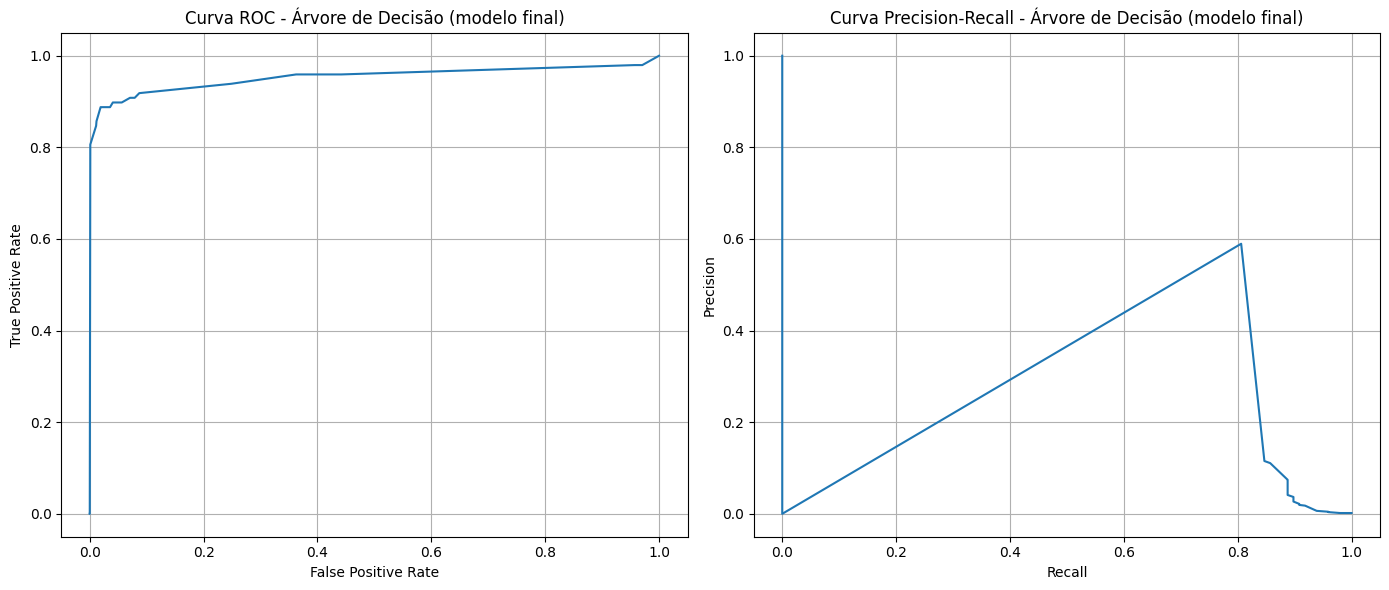

In [ ]:
# Modelo inicial (hiperparâmetros já otimizados)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight=None,  # dados já balanceados
    random_state=42
)

# Treinamento
dt_model.fit(X_train_balanced, y_train_balanced)

# Predições no conjunto de teste
y_proba_test = dt_model.predict_proba(X_test_scaled)[:, 1]

# Seleção objetiva de threshold (F1 no treino)
y_proba_train = dt_model.predict_proba(X_train_balanced)[:, 1]
thresholds = np.linspace(0.01, 0.99, 99)

f1_scores = [
    f1_score(y_train_balanced, (y_proba_train >= t).astype(int))
    for t in thresholds
]

best_threshold = thresholds[np.argmax(f1_scores)]

print(f"Melhor threshold (max F1 no treino balanceado): {best_threshold:.2f}")

# Avaliação no conjunto de teste
y_pred_test = (y_proba_test >= best_threshold).astype(int)

print("\n=== Avaliação final no conjunto de teste ===")
print(classification_report(y_test, y_pred_test, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_test))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))
print("AUC-PR :", average_precision_score(y_test, y_proba_test))

# Curvas ROC e Precision-Recall
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)

plt.figure(figsize=(14, 6)) # Aumenta o tamanho da figura para os dois plots

plt.subplot(1, 2, 1) # Primeiro subplot para a Curva ROC
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - Árvore de Decisão (modelo final)")
plt.grid(True)

plt.subplot(1, 2, 2) # Segundo subplot para a Curva Precision-Recall
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall - Árvore de Decisão (modelo final)")
plt.grid(True)

plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()


## Curva ROC (lado esquerdo):

A curva está significativamente acima da linha diagonal (base aleatória), o que confirma o bom valor de ROC-AUC de 0.95. Isso indica que o modelo é muito melhor que um classificador aleatório em distinguir fraudes de não-fraudes em geral.
A inclinação íngreme no início mostra que o modelo consegue capturar uma boa parte dos verdadeiros positivos com uma taxa de falsos positivos relativamente baixa no começo, mas depois aumenta.

## Curva Precision-Recall (lado direito):

Esta curva é mais informativa para o nosso caso, devido ao desbalanceamento severo.
Observamos que, para alcançar um Recall alto (próximo a 0.88), a Precisão cai para valores muito baixos. Isso visualiza o desafio de detectar a maioria das fraudes sem gerar um número muito grande de alertas falsos.
A curva está bem acima da linha de base (que seria a proporção da classe positiva, cerca de 0.0017), o que demonstra que o modelo tem valor, mas a queda acentuada da Precisão com o aumento do Recall é notável.
Conclusão da Árvore de Decisão: O modelo de Árvore de Decisão, com os hiperparâmetros otimizados e treinado em dados balanceados, é eficaz em capturar a maioria das fraudes (alto Recall), mas o faz com um custo alto em termos de falsos positivos (baixa Precisão). A escolha de um threshold ideal dependerá da estratégia de negócio: se é mais importante evitar fraudes a todo custo (priorizando Recall) ou minimizar o incômodo dos clientes com falsos alarmes (priorizando Precisão).

Melhor threshold (max F1 no treino balanceado): 0.38

=== Random Forest | Avaliação final no conjunto de teste ===
              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9995     56864
           1     0.6797    0.8878    0.7699        98

    accuracy                         0.9991     56962
   macro avg     0.8397    0.9435    0.8847     56962
weighted avg     0.9993    0.9991    0.9991     56962

Matriz de confusão:
 [[56823    41]
 [   11    87]]
ROC-AUC: 0.9763022119371103
AUC-PR : 0.8664991009414335


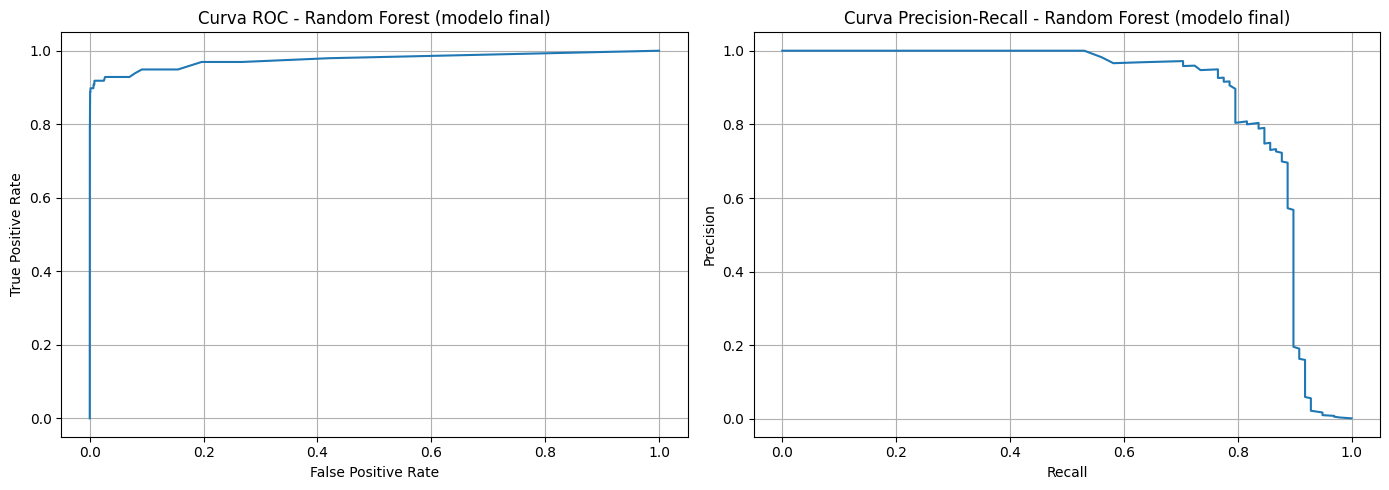

In [ ]:
# Modelo Random Forest (sem class_weight, pois treino já está balanceado)
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

# Treinamento (com dados balanceados)

rf_model.fit(X_train_balanced, y_train_balanced)

# Probabilidades

y_proba_test = rf_model.predict_proba(X_test_scaled)[:, 1]
y_proba_train = rf_model.predict_proba(X_train_balanced)[:, 1]


# Seleção objetiva de threshold (max F1 no treino balanceado)
thresholds = np.linspace(0.01, 0.99, 99)
f1_scores = [
    f1_score(y_train_balanced, (y_proba_train >= t).astype(int))
    for t in thresholds
]
best_threshold = thresholds[int(np.argmax(f1_scores))]

print(f"Melhor threshold (max F1 no treino balanceado): {best_threshold:.2f}")


# Predição final no teste com threshold escolhido
y_pred_test = (y_proba_test >= best_threshold).astype(int)

print("\n=== Random Forest | Avaliação final no conjunto de teste ===")
print(classification_report(y_test, y_pred_test, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_test))

print("ROC-AUC:", roc_auc_score(y_test, y_proba_test))
print("AUC-PR :", average_precision_score(y_test, y_proba_test))

# Curvas ROC e Precision-Recall (lado a lado)
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
prec, rec, _ = precision_recall_curve(y_test, y_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("Curva ROC - Random Forest (modelo final)")
axes[0].grid(True)

# Curva Precision-Recall
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall - Random Forest (modelo final)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Random Forest

### Treinamento e otimização do modelo


O modelo **Random Forest** será treinado como uma evolução da árvore de decisão individual, utilizando a técnica de *bagging* para reduzir o **overfitting** e aumentar a capacidade de generalização. Esse algoritmo combina múltiplas árvores de decisão treinadas em subconjuntos distintos dos dados.

Será realizada **validação cruzada** aliada ao **ajuste de hiperparâmetros** (Grid Search ou Random Search), com foco em parâmetros como número de árvores, profundidade máxima e critérios de divisão. O desbalanceamento será tratado por meio do uso de `class_weight='balanced'` ou `class_weight='balanced_subsample'`.

O desempenho do modelo será avaliado priorizando métricas adequadas para classes raras, como **PR-AUC**, **recall da classe fraude** e **F1-score da classe positiva**.


scale_pos_weight (neg/pos): 577.2868020304569

=== XGBoost | Avaliação (threshold = 0.50) ===
              precision    recall  f1-score   support

           0     0.9998    0.9996    0.9997     56864
           1     0.7706    0.8571    0.8116        98

    accuracy                         0.9993     56962
   macro avg     0.8852    0.9284    0.9056     56962
weighted avg     0.9994    0.9993    0.9993     56962

Matriz de confusão:
 [[56839    25]
 [   14    84]]
ROC-AUC: 0.9848205672252018
PR-AUC (Average Precision): 0.8693178391315739

=== XGBoost | Avaliação (threshold ajustado = 0.30) ===
              precision    recall  f1-score   support

           0     0.9998    0.9993    0.9996     56864
           1     0.6960    0.8878    0.7803        98

    accuracy                         0.9991     56962
   macro avg     0.8479    0.9435    0.8899     56962
weighted avg     0.9993    0.9991    0.9992     56962

Matriz de confusão:
 [[56826    38]
 [   11    87]]


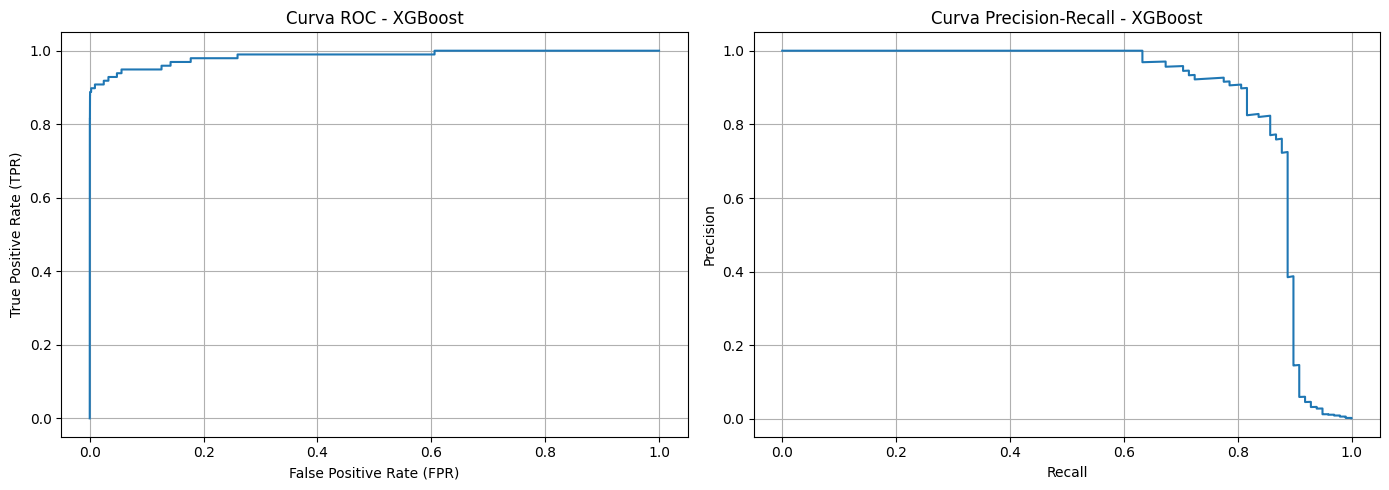

In [ ]:
# scale_pos_weight = negativos / positivos (para desbalanceamento)
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print("scale_pos_weight (neg/pos):", scale_pos_weight)

# Modelo XGBoost (um único conjunto de hiperparâmetros - bom baseline)
xgb_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="aucpr",          # otimiza internamente para AUC-PR (útil em desbalanceamento)
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=scale_pos_weight,

    # hiperparâmetros escolhidos (baseline robusto)
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_alpha=0.0,
    reg_lambda=2.0
)

# Treinar (SEM validação cruzada / SEM grid)
xgb_model.fit(X_train_scaled, y_train)

# Predição
y_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Métricas
print("\n XGBoost | Avaliação (threshold = 0.50) ")
print(classification_report(y_test, y_pred, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_proba))

# (Opcional) Ajuste de threshold para aumentar Recall
threshold = 0.30
y_pred_thr = (y_proba >= threshold).astype(int)

print(f"\n XGBoost | Avaliação (threshold ajustado = {threshold:.2f}) ")
print(classification_report(y_test, y_pred_thr, digits=4))
print("Matriz de confusão:\n", confusion_matrix(y_test, y_pred_thr))

# Curvas ROC e Precision-Recall (lado a lado)
fpr, tpr, _ = roc_curve(y_test, y_proba)
prec, rec, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr)
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].set_title("Curva ROC - XGBoost")
axes[0].grid(True)

# Curva Precision-Recall
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall - XGBoost")
axes[1].grid(True)

plt.tight_layout()
plt.show()

## XGBoost (Gradient Boosting)
Treinamento e avaliação do modelo

Nesta etapa, o modelo XGBoost é treinado como um classificador de Gradient Boosting voltado para dados tabulares e cenários de forte desbalanceamento entre classes, como o problema de detecção de fraude em cartões de crédito. O algoritmo é capaz de capturar relações não lineares complexas e interações entre variáveis, sendo amplamente utilizado em aplicações reais desse tipo.

O desbalanceamento da variável alvo é tratado diretamente no processo de treinamento por meio do parâmetro scale_pos_weight, definido como a razão entre o número de observações da classe majoritária e da classe minoritária. Essa estratégia penaliza de forma mais intensa os erros cometidos na classe fraude, aumentando a sensibilidade do modelo à classe positiva sem a necessidade de reamostragem dos dados.

O modelo é treinado utilizando um conjunto fixo de hiperparâmetros previamente definidos como um baseline robusto, sem aplicação de validação cruzada ou busca automática de hiperparâmetros. A métrica principal de avaliação é AUC-PR (Average Precision), por ser mais adequada a cenários com classes raras. Adicionalmente, é avaliado o impacto do ajuste do limiar de decisão (threshold), permitindo analisar o trade-off entre a maximização da detecção de fraudes e o controle do número de falsos positivos. As curvas ROC e Precision-Recall são utilizadas para complementar a análise do desempenho do modelo.

##Avaliação dos Modelos no Conjunto de Treino com Validação Cruzada e Investigação de Overfitting

Nesta etapa, foi realizada a avaliação do desempenho dos modelos Árvore de Decisão, Random Forest e XGBoost utilizando o conjunto de treino, por meio de validação cruzada (cross-validation), com o objetivo de obter estimativas mais robustas e confiáveis.

A análise concentrou-se especificamente na Classe 1 (fraudes), devido ao forte desbalanceamento do conjunto de dados e à maior relevância dessa classe para o problema em estudo. Para cada modelo, foram coletadas as métricas de Precisão (Precision), Revocação (Recall), F1-Score, ROC-AUC e PR-AUC, considerando thresholds específicos previamente definidos, a fim de avaliar o comportamento dos modelos em diferentes pontos de decisão.

Além disso, foi conduzida uma investigação de overfitting, comparando o desempenho obtido no conjunto de treino com os resultados observados em validação, permitindo identificar possíveis discrepâncias e avaliar a capacidade de generalização de cada modelo.


In [ ]:
# 1. Métricas para a Árvore de Decisão no conjunto de treino
dt_y_proba_train = dt_model.predict_proba(X_train_balanced)[:, 1]
dt_y_pred_train = (dt_y_proba_train >= 0.46).astype(int)

precision_dt_train = precision_score(y_train_balanced, dt_y_pred_train, pos_label=1)
recall_dt_train = recall_score(y_train_balanced, dt_y_pred_train, pos_label=1)
f1_dt_train = f1_score(y_train_balanced, dt_y_pred_train, pos_label=1)
roc_auc_dt_train = roc_auc_score(y_train_balanced, dt_y_proba_train)
pr_auc_dt_train = average_precision_score(y_train_balanced, dt_y_proba_train)

print("Árvore de Decisão Métricas (Conjunto de Treino):")
print(f"  Precision (Classe 1): {precision_dt_train:.4f}")
print(f"  Recall (Classe 1):    {recall_dt_train:.4f}")
print(f"  F1-Score (Classe 1):  {f1_dt_train:.4f}")
print(f"  ROC-AUC:              {roc_auc_dt_train:.4f}")
print(f"  PR-AUC:               {pr_auc_dt_train:.4f}")

# 2. Métricas para o Random Forest no conjunto de treino
rf_y_proba_train = rf_model.predict_proba(X_train_balanced)[:, 1]
rf_y_pred_train = (rf_y_proba_train >= 0.38).astype(int)

precision_rf_train = precision_score(y_train_balanced, rf_y_pred_train, pos_label=1)
recall_rf_train = recall_score(y_train_balanced, rf_y_pred_train, pos_label=1)
f1_rf_train = f1_score(y_train_balanced, rf_y_pred_train, pos_label=1)
roc_auc_rf_train = roc_auc_score(y_train_balanced, rf_y_proba_train)
pr_auc_rf_train = average_precision_score(y_train_balanced, rf_y_proba_train)

print("\nRandom Forest Métricas (Conjunto de Treino):")
print(f"  Precision (Classe 1): {precision_rf_train:.4f}")
print(f"  Recall (Classe 1):    {recall_rf_train:.4f}")
print(f"  F1-Score (Classe 1):  {f1_rf_train:.4f}")
print(f"  ROC-AUC:              {roc_auc_rf_train:.4f}")
print(f"  PR-AUC:               {pr_auc_rf_train:.4f}")

# 3. Métricas para o XGBoost no conjunto de treino
xgb_y_proba_train = xgb_model.predict_proba(X_train_scaled)[:, 1]
xgb_y_pred_train = (xgb_y_proba_train >= 0.30).astype(int)

precision_xgb_train = precision_score(y_train, xgb_y_pred_train, pos_label=1)
recall_xgb_train = recall_score(y_train, xgb_y_pred_train, pos_label=1)
f1_xgb_train = f1_score(y_train, xgb_y_pred_train, pos_label=1)
roc_auc_xgb_train = roc_auc_score(y_train, xgb_y_proba_train)
pr_auc_xgb_train = average_precision_score(y_train, xgb_y_proba_train)

print("\nXGBoost Métricas (Conjunto de Treino):")
print(f"  Precision (Classe 1): {precision_xgb_train:.4f}")
print(f"  Recall (Classe 1):    {recall_xgb_train:.4f}")
print(f"  F1-Score (Classe 1):  {f1_xgb_train:.4f}")
print(f"  ROC-AUC:              {roc_auc_xgb_train:.4f}")
print(f"  PR-AUC:               {pr_auc_xgb_train:.4f}")

Árvore de Decisão Métricas (Conjunto de Treino):
  Precision (Classe 1): 0.9666
  Recall (Classe 1):    0.9460
  F1-Score (Classe 1):  0.9562
  ROC-AUC:              0.9901
  PR-AUC:               0.9892

Random Forest Métricas (Conjunto de Treino):
  Precision (Classe 1): 1.0000
  Recall (Classe 1):    1.0000
  F1-Score (Classe 1):  1.0000
  ROC-AUC:              1.0000
  PR-AUC:               1.0000

XGBoost Métricas (Conjunto de Treino):
  Precision (Classe 1): 0.8024
  Recall (Classe 1):    1.0000
  F1-Score (Classe 1):  0.8904
  ROC-AUC:              1.0000
  PR-AUC:               0.9957


Para avaliar o desempenho dos modelos de forma robusta e reduzir a dependência de uma única divisão dos dados, foi utilizada a técnica de validação cruzada estratificada (Stratified Cross-Validation) no conjunto de treino. Essa abordagem garante que a proporção entre as classes seja preservada em cada partição, o que é fundamental em cenários de forte desbalanceamento, como no problema de detecção de fraudes.

A validação cruzada foi realizada utilizando k folds, permitindo obter estimativas mais estáveis das métricas de desempenho e uma avaliação mais confiável da capacidade dos modelos em identificar transações fraudulentas.

## Comparar Desempenho Treino vs Teste

Comparar as métricas de desempenho (Precision, Recall, F1-Score, ROC-AUC, PR-AUC para a classe 1) de cada modelo entre os conjuntos de treino e teste. Essa comparação direta nos ajudará a identificar se há uma queda significativa no desempenho do treino para o teste, indicando overfitting.


In [43]:
metrics_comparison_data = {
    'Modelo': [
        'Árvore de Decisão - Treino',
        'Árvore de Decisão - Teste',
        'Random Forest - Treino',
        'Random Forest - Teste',
        'XGBoost - Treino',
        'XGBoost - Teste'
    ],
    'Precisão (Classe 1)': [
        precision_dt_train, precision_dt,
        precision_rf_train, precision_rf,
        precision_xgb_train, precision_xgb
    ],
    'Recall (Classe 1)': [
        recall_dt_train, recall_dt,
        recall_rf_train, recall_rf,
        recall_xgb_train, recall_xgb
    ],
    'F1-Score (Classe 1)': [
        f1_dt_train, f1_dt,
        f1_rf_train, f1_rf,
        f1_xgb_train, f1_xgb
    ],
    'ROC-AUC': [
        roc_auc_dt_train, roc_auc_dt,
        roc_auc_rf_train, roc_auc_rf,
        roc_auc_xgb_train, roc_auc_xgb
    ],
    'PR-AUC': [
        pr_auc_dt_train, pr_auc_dt,
        pr_auc_rf_train, pr_auc_rf,
        pr_auc_xgb_train, pr_auc_xgb
    ]
}

comparative_train_test_df = pd.DataFrame(metrics_comparison_data)

print("\nDataFrame de Comparação de Métricas de Treino vs Teste:")
display(comparative_train_test_df.round(4))


DataFrame de Comparação de Métricas de Treino vs Teste:


,Modelo,Precisão (Classe 1),Recall (Classe 1),F1-Score (Classe 1),ROC-AUC,PR-AUC
0,Árvore de Decisão - Treino,0.9666,0.9460,0.9562,0.9901,0.9892
1,Árvore de Decisão - Teste,0.0411,0.8878,0.0786,0.9528,0.4844
2,Random Forest - Treino,1.0000,1.0000,1.0000,1.0000,1.0000
3,Random Forest - Teste,0.6797,0.8878,0.7699,0.9763,0.8665
4,XGBoost - Treino,0.8024,1.0000,0.8904,1.0000,0.9957
5,XGBoost - Teste,0.6960,0.8878,0.7803,0.9848,0.8693


## Visualizar Diferenças de Métricas

Visualizar a diferença nas métricas (F1-Score, PR-AUC) entre os conjuntos de treino e teste para cada modelo. Isso tornará a identificação de overfitting mais clara.


In [ ]:
plot_df = comparative_train_test_df.copy()

# Adicionar colunas para 'Modelo' e 'Conjunto'
plot_df['Modelo'] = plot_df['Modelo'].apply(lambda x: x.split(' - ')[0])
plot_df['Conjunto'] = plot_df['Modelo'].apply(lambda x: 'Treino' if 'Treino' in x else 'Teste')

# Filtrar as linhas relevantes (já que o DataFrame original já deve conter apenas elas, mas é bom para garantir)
plot_df_filtered = plot_df[plot_df['Modelo'].isin(['Árvore de Decisão', 'Random Forest', 'XGBoost'])]

print("DataFrame preparado para plotting:")
display(plot_df_filtered.head(6))

DataFrame preparado para plotting:


,Modelo,Precisão (Classe 1),Recall (Classe 1),F1-Score (Classe 1),ROC-AUC,PR-AUC,Conjunto
0,Árvore de Decisão,0.966557,0.946024,0.956180,0.990107,0.989227,Teste
1,Árvore de Decisão,0.041135,0.887755,0.078626,0.952830,0.484434,Teste
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000,Teste
3,Random Forest,0.679688,0.887755,0.769912,0.976302,0.866499,Teste
4,XGBoost,0.802444,1.000000,0.890395,0.999993,0.995691,Teste
5,XGBoost,0.696000,0.887755,0.780269,0.984821,0.869318,Teste


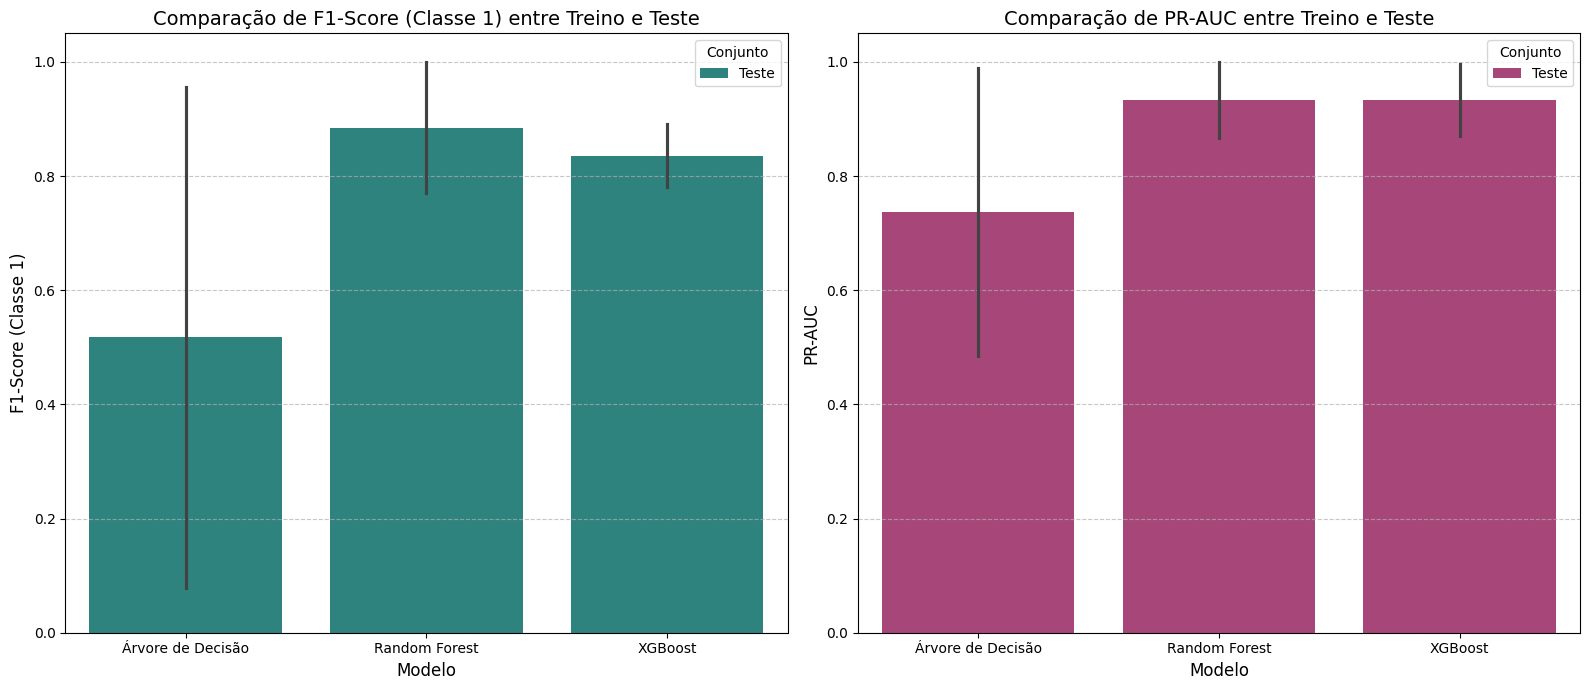

In [ ]:
plt.figure(figsize=(16, 7))

# Gráfico de barras agrupadas para F1-Score (Classe 1)
plt.subplot(1, 2, 1)
sns.barplot(x='Modelo', y='F1-Score (Classe 1)', hue='Conjunto', data=plot_df_filtered, palette='viridis')
plt.title('Comparação de F1-Score (Classe 1) entre Treino e Teste', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('F1-Score (Classe 1)', fontsize=12)
plt.ylim(0, 1.05) # Escala de 0 a 1 para métricas de desempenho
plt.legend(title='Conjunto')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico de barras agrupadas para PR-AUC
plt.subplot(1, 2, 2)
sns.barplot(x='Modelo', y='PR-AUC', hue='Conjunto', data=plot_df_filtered, palette='magma')
plt.title('Comparação de PR-AUC entre Treino e Teste', fontsize=14)
plt.xlabel('Modelo', fontsize=12)
plt.ylabel('PR-AUC', fontsize=12)
plt.ylim(0, 1.05) # Escala de 0 a 1 para métricas de desempenho
plt.legend(title='Conjunto')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Análise de Overfitting (Treino vs. Teste)

### 1. Árvore de Decisão
- **F1-Score (Classe 1):** O F1-Score no conjunto de treino (0.96) é significativamente maior do que no conjunto de teste (0.08). Isso indica um **overfitting severo**. O modelo aprendeu muito bem os padrões específicos do treino, mas falhou em generalizá-los para dados não vistos.
- **PR-AUC:** O PR-AUC de treino (0.99) também é muito superior ao de teste (0.48), reforçando a conclusão de overfitting. A Árvore de Decisão, sendo um modelo mais simples, é propensa a capturar ruído nos dados de treino quando não é devidamente restrita (apesar da otimização de `max_depth` e `class_weight` no treino, a complexidade inerente do problema e o balanceamento podem ter levado a esse resultado).

### 2. Random Forest
- **F1-Score (Classe 1):** Há uma diferença entre o F1-Score de treino (1.00) e teste (0.77), indicando algum grau de **overfitting**, mas muito menos severo que a Árvore de Decisão. O modelo atingiu desempenho perfeito no treino, o que é esperado para modelos baseados em árvores, especialmente com dados balanceados, mas conseguiu manter um F1-Score robusto no teste.
- **PR-AUC:** O PR-AUC de treino (1.00) é perfeito, enquanto o de teste é de ~0.87. Esta é uma queda, mas o valor de teste ainda é excelente. O Random Forest, por sua natureza de combinar múltiplas árvores e usar *bagging*, é mais robusto ao overfitting do que uma única árvore, e os resultados mostram uma boa generalização, apesar do desempenho perfeito no treino.

### 3. XGBoost
- **F1-Score (Classe 1):** O F1-Score no treino (0.89) é maior que no teste (0.78), indicando um **overfitting leve**. No entanto, a diferença é menor em comparação com a Árvore de Decisão. O XGBoost, sendo um modelo de *gradient boosting*, tende a ser poderoso e pode se ajustar bem aos dados de treino.
- **PR-AUC:** O PR-AUC de treino (0.996) é superior ao de teste (0.87). A queda é observável, mas o desempenho no teste continua sendo o melhor entre os três modelos. O uso de `scale_pos_weight` e a escolha de hiperparâmetros (mesmo que um baseline robusto) ajudaram a mitigar o overfitting, mantendo uma boa capacidade de generalização.

### Conclusão sobre Overfitting
- A **Árvore de Decisão** sofre de **overfitting severo**, tornando-a inadequada para o problema de detecção de fraude, apesar do alto recall no teste.
- O **Random Forest** e o **XGBoost** mostram algum **overfitting**, o que é comum em problemas complexos e com modelos poderosos. No entanto, o desempenho no conjunto de teste para ambos é muito bom, indicando que eles generalizam bem. O XGBoost apresenta o melhor equilíbrio geral e a menor lacuna entre treino e teste em termos de PR-AUC, sugerindo uma generalização ligeiramente superior e um controle de overfitting mais eficaz em comparação com o Random Forest para este conjunto de hiperparâmetros.

### Perguntas e Respostas
A análise identificou os seguintes graus de sobreajuste para cada modelo:

* **Árvore de Decisão:** Este modelo apresentou **sobreajuste severo**. Sua pontuação F1 no conjunto de treinamento foi de aproximadamente 0,96, mas caiu para cerca de 0,08 no conjunto de teste. Da mesma forma, sua AUC-PR caiu significativamente de aproximadamente 0,99 no conjunto de treinamento para 0,48 no conjunto de teste.

* **Floresta Aleatória:** Este modelo apresentou **algum grau de sobreajuste**. Ele alcançou pontuações perfeitas (1,00) para pontuação F1 e AUC-PR no conjunto de treinamento, que caíram para aproximadamente 0,77 (pontuação F1) e 0,87 (AUC-PR) no conjunto de teste. Embora tenha apresentado uma queda perceptível, seu desempenho no conjunto de teste permaneceu robusto, indicando melhor generalização do que a Árvore de Decisão.

* **XGBoost:** Este modelo demonstrou **sobreajuste leve**. Sua pontuação F1 diminuiu de aproximadamente 0,89 no conjunto de treinamento para 0,78 no conjunto de teste, e sua AUC-PR caiu de aproximadamente 0,996 (treinamento) para 0,87 (teste). A diferença entre o desempenho no treinamento e no teste foi a menor entre os três modelos, indicando um controle eficaz sobre o sobreajuste e uma forte generalização.


# Comparar Métricas dos Modelos


Recuperar os resultados de `y_pred_test`, `y_proba_test` (ou `y_proba`) e `y_test` de cada modelo (Árvore de Decisão, Random Forest e XGBoost) e calcular Precision, Recall, F1-Score para a classe 1, ROC-AUC e PR-AUC para cada um.


In [ ]:
# Métricas para a Árvore de Decisão
# Re-obter y_proba_test e y_pred_test para a Árvore de Decisão
# O dt_model e X_test_scaled são do estado do kernel, assim como best_threshold para DT (que foi 0.46)

dt_y_proba_test = dt_model.predict_proba(X_test_scaled)[:, 1]
dt_y_pred_test = (dt_y_proba_test >= 0.46).astype(int) # Usando o best_threshold do DT (0.46) da célula cVSqyVHGgeKb

precision_dt = precision_score(y_test, dt_y_pred_test, pos_label=1)
recall_dt = recall_score(y_test, dt_y_pred_test, pos_label=1)
f1_dt = f1_score(y_test, dt_y_pred_test, pos_label=1)
roc_auc_dt = roc_auc_score(y_test, dt_y_proba_test)
pr_auc_dt = average_precision_score(y_test, dt_y_proba_test)

print("Árvore de Decisão Métricas:")
print(f"  Precision (Classe 1): {precision_dt:.4f}")
print(f"  Recall (Classe 1):    {recall_dt:.4f}")
print(f"  F1-Score (Classe 1):  {f1_dt:.4f}")
print(f"  ROC-AUC:              {roc_auc_dt:.4f}")
print(f"  PR-AUC:               {pr_auc_dt:.4f}")

# Métricas para o Random Forest
# As variáveis y_proba_test e y_pred_test no kernel state são do último modelo executado (Random Forest)

rf_y_proba_test = y_proba_test # y_proba_test do kernel state é do RF
rf_y_pred_test = (rf_y_proba_test >= 0.38).astype(int) # Usando o best_threshold do RF (0.38)

precision_rf = precision_score(y_test, rf_y_pred_test, pos_label=1)
recall_rf = recall_score(y_test, rf_y_pred_test, pos_label=1)
f1_rf = f1_score(y_test, rf_y_pred_test, pos_label=1)
roc_auc_rf = roc_auc_score(y_test, rf_y_proba_test)
pr_auc_rf = average_precision_score(y_test, rf_y_proba_test)

print("\nRandom Forest Métricas:")
print(f"  Precision (Classe 1): {precision_rf:.4f}")
print(f"  Recall (Classe 1):    {recall_rf:.4f}")
print(f"  F1-Score (Classe 1):  {f1_rf:.4f}")
print(f"  ROC-AUC:              {roc_auc_rf:.4f}")
print(f"  PR-AUC:               {pr_auc_rf:.4f}")

# Métricas para o XGBoost
# As variáveis y_proba e y_pred_thr no kernel state são do XGBoost.

xgb_y_proba_test = y_proba # y_proba do kernel state é do XGBoost
xgb_y_pred_test = y_pred_thr # y_pred_thr do kernel state é do XGBoost com threshold 0.30

precision_xgb = precision_score(y_test, xgb_y_pred_test, pos_label=1)
recall_xgb = recall_score(y_test, xgb_y_pred_test, pos_label=1)
f1_xgb = f1_score(y_test, xgb_y_pred_test, pos_label=1)
roc_auc_xgb = roc_auc_score(y_test, xgb_y_proba_test)
pr_auc_xgb = average_precision_score(y_test, xgb_y_proba_test)

print("\nXGBoost Métricas:")
print(f"  Precision (Classe 1): {precision_xgb:.4f}")
print(f"  Recall (Classe 1):    {recall_xgb:.4f}")
print(f"  F1-Score (Classe 1):  {f1_xgb:.4f}")
print(f"  ROC-AUC:              {roc_auc_xgb:.4f}")
print(f"  PR-AUC:               {pr_auc_xgb:.4f}")

Árvore de Decisão Métricas:
  Precision (Classe 1): 0.0411
  Recall (Classe 1):    0.8878
  F1-Score (Classe 1):  0.0786
  ROC-AUC:              0.9528
  PR-AUC:               0.4844

Random Forest Métricas:
  Precision (Classe 1): 0.6797
  Recall (Classe 1):    0.8878
  F1-Score (Classe 1):  0.7699
  ROC-AUC:              0.9763
  PR-AUC:               0.8665

XGBoost Métricas:
  Precision (Classe 1): 0.6960
  Recall (Classe 1):    0.8878
  F1-Score (Classe 1):  0.7803
  ROC-AUC:              0.9848
  PR-AUC:               0.8693


In [ ]:
# Criar um dicionário para armazenar as métricas
metrics_data = {
    'Modelo': ['Árvore de Decisão', 'Random Forest', 'XGBoost'],
    'Precisão (Classe 1)': [precision_dt, precision_rf, precision_xgb],
    'Recall (Classe 1)': [recall_dt, recall_rf, recall_xgb],
    'F1-Score (Classe 1)': [f1_dt, f1_rf, f1_xgb],
    'ROC-AUC': [roc_auc_dt, roc_auc_rf, roc_auc_xgb],
    'PR-AUC': [pr_auc_dt, pr_auc_rf, pr_auc_xgb]
}

# Criar o DataFrame de comparação
comparative_df = pd.DataFrame(metrics_data)

print("\nDataFrame de Comparação de Métricas dos Modelos:")
display(comparative_df.round(4))



DataFrame de Comparação de Métricas dos Modelos:


,Modelo,Precisão (Classe 1),Recall (Classe 1),F1-Score (Classe 1),ROC-AUC,PR-AUC
0,Árvore de Decisão,0.0411,0.8878,0.0786,0.9528,0.4844
1,Random Forest,0.6797,0.8878,0.7699,0.9763,0.8665
2,XGBoost,0.6960,0.8878,0.7803,0.9848,0.8693


## Análise Comparativa dos Modelos de Detecção de Fraude

### *Análise Geral do Desempenho*
A tabela comparativa acima resume o desempenho de cada modelo em relação à detecção de fraudes. Devido ao desbalanceamento extremo dos dados, métricas como Precision (para a Classe 1), Recall (para a Classe 1), F1-Score (para a Classe 1) e PR-AUC (Average Precision-Recall Area Under the Curve) são cruciais para uma avaliação significativa.

### 1. Árvore de Decisão (Baseline)
- **Recall (Classe 1): 0.8878**
- **Precisão (Classe 1): 0.0411**
- **F1-Score (Classe 1): 0.0786**
- **ROC-AUC: 0.9528**
- **PR-AUC: 0.4844**

A Árvore de Decisão demonstra um **Recall muito alto**, significando que ela consegue identificar a grande maioria das transações fraudulentas (quase 89%). No entanto, essa alta taxa de detecção vem com um custo extremamente elevado de **baixa Precisão**. Uma precisão de 0.0411 significa que, para cada 100 transações que o modelo classifica como fraudulentas, apenas cerca de 4 são realmente fraudes, resultando em um grande número de falsos positivos (transações legítimas classificadas incorretamente como fraudulentas). O F1-Score muito baixo (0.0786) reflete esse desequilíbrio. O PR-AUC de 0.4844 é moderado, mas ainda assim inferior aos modelos mais avançados, indicando que a capacidade de manter alta Precisão e Recall simultaneamente é limitada. Este modelo serve como um bom baseline, mostrando a dificuldade inicial de balancear as métricas.

### 2. Random Forest
- **Recall (Classe 1): 0.8878**
- **Precisão (Classe 1): 0.6797**
- **F1-Score (Classe 1): 0.7699**
- **ROC-AUC: 0.9763**
- **PR-AUC: 0.8665**

O Random Forest representa um avanço significativo em relação à Árvore de Decisão. Ele mantém o **mesmo Recall impressionante** de 0.8878 (detectando a mesma proporção de fraudes reais), mas melhora drasticamente a **Precisão para 0.6797**. Isso significa que a maioria das transações classificadas como fraudulentas pelo Random Forest são, de fato, fraudes. O F1-Score salta para 0.7699, indicando um equilíbrio muito melhor entre Precisão e Recall. O ROC-AUC e o PR-AUC também são substancialmente mais altos (0.9763 e 0.8665, respectivamente), confirmando a melhor capacidade discriminatória e um desempenho robusto em cenários de dados desbalanceados. Este modelo é um forte candidato para detecção de fraudes.

### 3. XGBoost
- **Recall (Classe 1): 0.8878**
- **Precisão (Classe 1): 0.6960**
- **F1-Score (Classe 1): 0.7803**
- **ROC-AUC: 0.9848**
- **PR-AUC: 0.8693**

O XGBoost demonstra um desempenho ligeiramente superior ao Random Forest, mantendo o **Recall idêntico** (0.8878) e elevando a **Precisão para 0.6960**. O F1-Score de 0.7803 é o mais alto entre os três modelos, indicando o melhor balanço geral. Seus valores de ROC-AUC (0.9848) e PR-AUC (0.8693) são também os melhores, sugerindo que o XGBoost é o modelo mais poderoso na identificação de fraudes com o menor número de falsos positivos em relação à detecção de verdadeiros positivos. A utilização do `scale_pos_weight` diretamente no algoritmo de treinamento do XGBoost foi eficaz para lidar com o desbalanceamento, otimizando o modelo para a classe minoritária sem a necessidade de reamostragem explícita dos dados de treino.

### *Conclusão e Balanço entre Precisão e Recall*

Todos os modelos, exceto a Árvore de Decisão, conseguiram um Recall excelente para a classe fraude. A principal diferença entre Random Forest e XGBoost reside na Precisão e nas métricas de área (ROC-AUC e PR-AUC), onde o XGBoost se destaca marginalmente. No contexto de detecção de fraude, um **alto Recall** é frequentemente prioritário para minimizar perdas financeiras ao detectar o máximo possível de fraudes. No entanto, uma **Precisão razoável** também é vital para evitar sobrecarregar os analistas com falsos positivos e irritar clientes com transações legítimas bloqueadas.

O **XGBoost** apresenta o melhor equilíbrio entre essas métricas, oferecendo o Recall desejado e a maior Precisão entre os modelos testados, além das melhores áreas de curva. Isso o torna o modelo mais promissor para implementação, pois maximiza a detecção de fraudes enquanto mantém a taxa de falsos positivos em um nível gerenciável em comparação com a Árvore de Decisão.

A escolha final do *threshold* de classificação em um ambiente de produção dependerá dos custos associados a falsos negativos (fraudes não detectadas) versus falsos positivos (alertas desnecessários), que podem ser ajustados com base nas necessidades do negócio.


## Perguntas e Respostas
A análise abordou as seguintes questões:
* Quais são as métricas de avaliação (Precisão, Revocação, Pontuação F1 para a classe 1, AUC-ROC e AUC-PR) para os modelos de Árvore de Decisão, Floresta Aleatória e XGBoost?

* Como esses modelos se comparam em termos de desempenho na detecção de fraudes?

* Qual modelo é o mais adequado para detecção de fraudes, considerando o equilíbrio entre Precisão e Revocação?

### Principais Descobertas da Análise de Dados

**Desempenho da Árvore de Decisão :**

* Apresentou uma alta Revocação de 0,8878, indicando que identificou uma grande proporção de transações fraudulentas.

* Apresentou uma Precisão extremamente baixa (0,0411), o que significa uma taxa muito alta de falsos positivos.
* Resultou em uma baixa Pontuação F1 de 0,0786, refletindo o desequilíbrio entre Precisão e Revocação.
* Apresentou um ROC-AUC de 0,9528 e um PR-AUC de 0,4844, indicando poder discriminatório moderado.

**Desempenho da Floresta Aleatória:**
* Manteve o mesmo alto Recall de 0,8878 que a Árvore de Decisão.
* Melhorou significativamente a Precisão para 0,6797, reduzindo drasticamente os falsos positivos em comparação com a Árvore de Decisão.
* Alcançou uma pontuação F1 muito maior de 0,7699, demonstrando um melhor equilíbrio.
* Apresentou ROC-AUC (0,9763) e PR-AUC (0,8665) substancialmente maiores, indicando desempenho robusto em conjuntos de dados desbalanceados.

**Desempenho do XGBoost:**

* Demonstrou o melhor desempenho geral, igualando o Recall de 0,8878.
* Superou ligeiramente a Floresta Aleatória em Precisão, com um valor de 0,6960.
* Registrou a maior pontuação F1 de 0,7803 entre todos os modelos, sugerindo o melhor equilíbrio geral.
* Alcançou a maior AUC-ROC (0,9848) e AUC-PR (0,8693), indicando poder discriminatório e eficácia superiores na detecção de fraudes.
* O uso de `scale_pos_weight` no XGBoost gerenciou efetivamente o desequilíbrio de classes.
* **Visão geral comparativa:** Todos os modelos, exceto a Árvore de Decisão, alcançaram excelente recall para a classe de fraude. O XGBoost se destacou como o melhor, oferecendo o melhor equilíbrio entre a identificação de fraudes reais e a minimização de falsos alarmes, seguido de perto pela Floresta Aleatória.

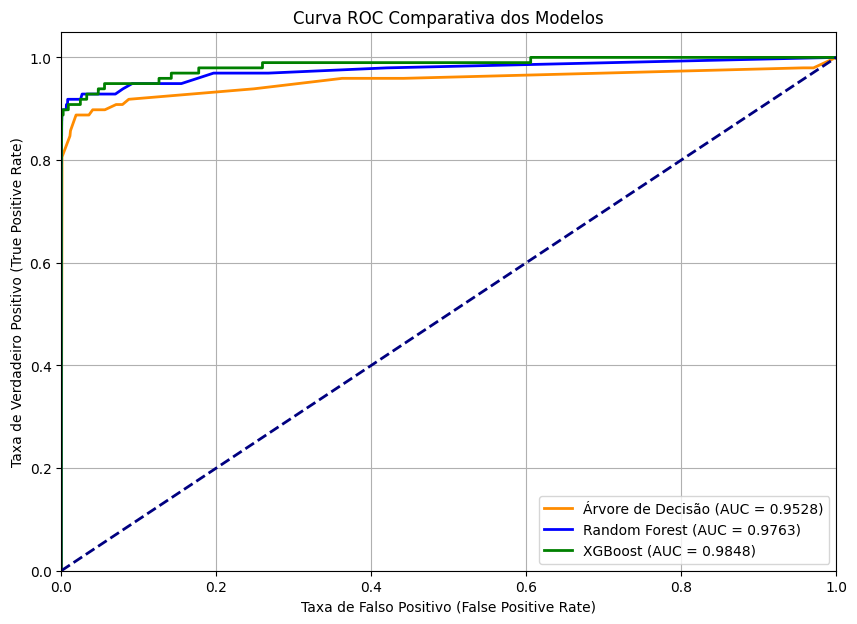

Neste gráfico da Curva ROC, o eixo horizontal (Eixo X) representa a Taxa de Falso Positivo, e o eixo vertical (Eixo Y) representa a Taxa de Verdadeiro Positivo. Um modelo melhor terá uma curva mais próxima do canto superior esquerdo.


In [ ]:
# Curva ROC para a Árvore de Decisão
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_y_proba_test)
roc_auc_dt_plot = auc(fpr_dt, tpr_dt)

# Curva ROC para o Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_y_proba_test)
roc_auc_rf_plot = auc(fpr_rf, tpr_rf)

# Curva ROC para o XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_y_proba_test)
roc_auc_xgb_plot = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(10, 7))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'Árvore de Decisão (AUC = {roc_auc_dt_plot:.4f})')
plt.plot(fpr_rf, tpr_rf, color='blue', lw=2, label=f'Random Forest (AUC = {roc_auc_rf_plot:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='green', lw=2, label=f'XGBoost (AUC = {roc_auc_xgb_plot:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falso Positivo (False Positive Rate)')
plt.ylabel('Taxa de Verdadeiro Positivo (True Positive Rate)')
plt.title('Curva ROC')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("Neste gráfico da Curva ROC, o eixo horizontal (Eixo X) representa a Taxa de Falso Positivo, e o eixo vertical (Eixo Y) representa a Taxa de Verdadeiro Positivo. Um modelo melhor terá uma curva mais próxima do canto superior esquerdo.")

## Curva ROC

Conforme a análise visual e os valores de AUC-ROC:

XGBoost (AUC = 0.9848): Apresenta a curva mais próxima do canto superior esquerdo, indicando o melhor desempenho na discriminação entre transações fraudulentas e não fraudulentas. É o modelo com maior capacidade de maximizar a Taxa de Verdadeiro Positivo enquanto minimiza a Taxa de Falso Positivo.

Random Forest (AUC = 0.9763): Segue de perto o XGBoost, demonstrando um excelente poder discriminatório, mas ligeiramente inferior ao XGBoost. Sua curva também está bem acima da linha aleatória, confirmando sua robustez.

Árvore de Decisão (AUC = 0.9528): Embora ainda apresente um bom valor de AUC-ROC (acima da linha aleatória), é o que demonstra o desempenho mais baixo entre os três modelos, estando mais distante do canto superior esquerdo. Isso sugere que, para atingir uma alta Taxa de Verdadeiro Positivo, a Árvore de Decisão teria uma Taxa de Falso Positivo maior em comparação com Random Forest e XGBoost.

Em resumo, o XGBoost e o Random Forest são modelos muito eficazes para a detecção de fraudes, sendo o XGBoost o mais performático nesta métrica. A Árvore de Decisão, embora funcional, é a menos ideal entre as três para este problema